# Experiment 2B: Latent Inversion and PCA

**Experiment:** Exp 2B

SVM classification on CNN/encoder/E4E features + PCA analysis of latent space separability (Tables 5.6-5.8, Figure 5.8).

---

In [ ]:
import os
!pip install gdown --upgrade

if os.path.isdir("/content/drive/MyDrive/colab-sg2-ada-pytorch"):
    %cd "/content/drive/MyDrive/colab-sg2-ada-pytorch/stylegan2-ada-pytorch"
elif os.path.isdir("/content/drive/"):
    #install script
    %cd "/content/drive/MyDrive/"
    !mkdir colab-sg2-ada-pytorch
    %cd colab-sg2-ada-pytorch
    !git clone https://github.com/JunTierSS/stylegan2-ada
    %cd stylegan2-ada-pytorch
    !mkdir downloads
    !mkdir datasets
    !mkdir pretrained
    !gdown --id 1-5xZkD8ajXw1DdopTkH_rAoCsD72LhKU -O /content/drive/MyDrive/colab-sg2-ada-pytorch/stylegan2-ada-pytorch/pretrained/wikiart.pkl
else:
    !git clone https://github.com/JunTierSS/stylegan2-ada
    %cd stylegan2-ada-pytorch
    !mkdir downloads
    !mkdir datasets
    !mkdir pretrained
    %cd pretrained
    !gdown --id 1-5xZkD8ajXw1DdopTkH_rAoCsD72LhKU
    %cd ../

/content/drive/MyDrive/colab-sg2-ada-pytorch/stylegan2-ada-pytorch


In [ ]:
pip install ninja

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 16.5 MB/s eta 0:00:00


In [ ]:
pip install opensimplex

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.0/268.0 kB 21.6 MB/s eta 0:00:00


In [8]:
# (2) Rutas
ZIP ="/content/drive/MyDrive/TESIS/splits/by_patient_30test1/test.zip"
DEST = "/content/localdata"                 # carpeta base local
UNZIP_DIR = f"{DEST}/test_unzipped"        # donde se extraerá el zip

import os, shutil, pathlib, subprocess

# (3) Crear carpeta destino y copiar el ZIP localmente (I/O mucho más rápido)
os.makedirs(DEST, exist_ok=True)
local_zip = f"{DEST}/test.zip"
shutil.copy2(ZIP, local_zip)
print("ZIP copiado a:", local_zip)

# (4) Descomprimir (silencioso, sobrescribe si ya existe)
os.makedirs(UNZIP_DIR, exist_ok=True)
!unzip -q -o "/content/localdata/test.zip" -d "/content/localdata/test_unzipped"

# (5) (Opcional) eliminar carpeta __MACOSX si existe
!find "/content/localdata/test_unzipped" -type d -name "__MACOSX" -prune -exec rm -rf {} +

# (6) Mostrar estructura principal para que ubiques DATA_ROOT / TEST_ROOT
print("Contenido de", UNZIP_DIR)
!ls -lah "/content/localdata/test_unzipped" | head -n 50

ZIP copiado a: /content/localdata/test.zip
Contenido de /content/localdata/test_unzipped
total 64K
drwxr-xr-x 5 root root 4.0K Dec 15 23:04 .
drwxr-xr-x 3 root root 4.0K Dec 15 23:04 ..
drwxr-xr-x 2 root root  24K Dec 15 23:04 glioma
drwxr-xr-x 2 root root  12K Dec 15 23:04 meningioma
drwxr-xr-x 2 root root  20K Dec 15 23:04 pituitary


In [ ]:
# (2) Rutas
ZIP ="/content/drive/MyDrive/TESIS/splits/by_patient_30test1/train.zip"
DEST = "/content/localdata"                 # carpeta base local
UNZIP_DIR = f"{DEST}/train_unzipped"        # donde se extraerá el zip

import os, shutil, pathlib, subprocess

# (3) Crear carpeta destino y copiar el ZIP localmente (I/O mucho más rápido)
os.makedirs(DEST, exist_ok=True)
local_zip = f"{DEST}/train.zip"
shutil.copy2(ZIP, local_zip)
print("ZIP copiado a:", local_zip)

# (4) Descomprimir (silencioso, sobrescribe si ya existe)
os.makedirs(UNZIP_DIR, exist_ok=True)
!unzip -q -o "/content/localdata/train.zip" -d "/content/localdata/train_unzipped"

# (5) (Opcional) eliminar carpeta __MACOSX si existe
!find "/content/localdata/train_unzipped" -type d -name "__MACOSX" -prune -exec rm -rf {} +

# (6) Mostrar estructura principal para que ubiques DATA_ROOT / TEST_ROOT
print("Contenido de", UNZIP_DIR)
!ls -lah "/content/localdata/train_unzipped" | head -n 50

ZIP copiado a: /content/localdata/train.zip
Contenido de /content/localdata/train_unzipped
total 132K
drwxr-xr-x 5 root root 4.0K Dec 11 02:52 .
drwxr-xr-x 4 root root 4.0K Dec 11 02:52 ..
drwxr-xr-x 2 root root  52K Dec 11 02:52 glioma
drwxr-xr-x 2 root root  32K Dec 11 02:52 meningioma
drwxr-xr-x 2 root root  36K Dec 11 02:52 pituitary


In [ ]:
pip install lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 5.5 MB/s eta 0:00:00


In [ ]:
!python export_weights.py /content/drive/MyDrive/TESIS/StyleGan2/Modelsinge/00000-finalnuevoinge-cond-mirror-24gb-gpu-kimg1000-batch32-ada-target0.6-bg/network-snapshot-000600.pkl /content/drive/MyDrive/TESIS/StyleGan2/Modelsinge/stylegan_brain_rosinality.pt

/content/drive/MyDrive/colab-sg2-ada-pytorch/stylegan2-ada-pytorch/export_weights.py:38: SyntaxWarning: invalid escape sequence '\d'
  n_mapping =  max([int(re.findall("(\d+)", n)[0]) for n in mapping_names]) + 1
/content/drive/MyDrive/colab-sg2-ada-pytorch/stylegan2-ada-pytorch/export_weights.py:39: SyntaxWarning: invalid escape sequence '\d'
  resolution =  max([int(re.findall("(\d+)", n)[0]) for n in sythesis_names])


In [ ]:
import os
!pip install gdown --upgrade

if os.path.isdir("/content/drive/MyDrive/encoder4editing"):
    %cd "/content/drive/MyDrive/encoder4editing"
elif os.path.isdir("/content/drive/"):
    #install script
    %cd "/content/drive/MyDrive/"
    !mkdir encoder4editing
    %cd encoder4editing
    !git clone https://github.com/omertov/encoder4editing.git
    %cd encoder4editing
else:
    !git clone https://github.com/omertov/encoder4editing.git
    %cd encoder4editing
    %cd ../

/content/drive/MyDrive/encoder4editing


In [ ]:
!python scripts/train.py \
--dataset_type brain_mri_encode \
--exp_dir /content/drive/MyDrive/TESIS/StyleGan2/encoder4e4nuevofinal100kfinal \
--start_from_latent_avg \
--use_w_pool \
--w_discriminator_lambda 0.1 \
--progressive_start 20000 \
--id_lambda 0.5 \
--val_interval 10000 \
--max_steps 100000 \
--stylegan_size 256 \
--stylegan_weights /content/drive/MyDrive/encoder4editing/encoder4editing/stylegan2-ffhq-config-f.pt \
--workers 8 \
--batch_size 8 \
--test_batch_size 4 \
--w_discriminator_lr 1e-04 \
--test_workers 4

Se han truncado las últimas 5000 líneas del flujo de salida.
	total_delta_loss =  98.71861267089844
	loss_id =  0.09352549910545349
	id_improve =  -0.0935254842042923
	loss_l2 =  0.06243855506181717
	loss_lpips =  0.22791919112205505
	loss =  0.45196181535720825
Metrics for train, step 73800
	d_real_loss =  0.3023800849914551
	d_fake_loss =  0.3580927848815918
	discriminator_loss =  0.6604728698730469
	encoder_discriminator_loss =  1.3291438817977905
	delta1_loss =  7.1373372077941895
	delta2_loss =  6.926185607910156
	delta3_loss =  7.166469097137451
	delta4_loss =  6.775876998901367
	delta5_loss =  6.953356742858887
	delta6_loss =  7.321743011474609
	delta7_loss =  6.212166786193848
	delta8_loss =  6.183231353759766
	delta9_loss =  6.464658737182617
	delta10_loss =  6.286387920379639
	delta11_loss =  6.530542850494385
	delta12_loss =  5.661434650421143
	delta13_loss =  10.140987396240234
	total_delta_loss =  89.7603759765625
	loss_id =  0.10393428802490234
	id_improve =  -0.103934273

In [ ]:
import torch
import numpy as np
from torchvision import transforms, datasets # Corrected import to include datasets
from torch.utils.data import DataLoader
from PIL import Image
from pathlib import Path
import json
from tqdm import tqdm
import sys
import argparse # For reconstructing opts

# Add the encoder4editing directory to sys.path if not already there
encoder4editing_repo_path = "/content/drive/MyDrive/encoder4editing/encoder4editing"
if encoder4editing_repo_path not in sys.path:
    sys.path.append(encoder4editing_repo_path)

from models.encoders import psp_encoders  # Corrected Import: Import Encoder4Editing from models.encoders

# ImageFolderWithPaths class (copied from cnn_encoder_features.py for self-containment)
class ImageFolderWithPaths(datasets.ImageFolder):
    """
    Igual que ImageFolder, pero __getitem__ devuelve (img, label, path).
    """
    def __getitem__(self, index: int):
        img, label = super().__getitem__(index)
        path, _ = self.samples[index]
        return img, label, path

def extract_wplus_from_psp_encoder(
    encoder_ckpt: str,
    data_root: str,
    out_npz: str,
    *,
    batch_size: int = 64,
    num_workers: int = 2,
    device: str = "cuda",
):
    """
    Extrae los latentes W+ de las imágenes utilizando el encoder PSP (Encoder4Editing).

    Los resultados se guardan en un archivo .npz con:
        - Fw: Latentes W+ (embeddings de las imágenes)
        - paths: Rutas de las imágenes
        - y: Etiquetas (si corresponde)
        - classes: Clases del dataset
        - meta: Información del encoder y dataset
    """
    dev = torch.device("cuda" if (device == "cuda" and torch.cuda.is_available()) else "cpu")
    print(f"[extract_wplus_from_psp_encoder] Device: {dev}")

    # Cargar el checkpoint del encoder PSP (Encoder4Editing)
    ckpt = torch.load(encoder_ckpt, map_location="cpu")

    # Extract parameters from 'opts' dictionary in the checkpoint
    opts_dict = ckpt['opts']
    opts = argparse.Namespace(**opts_dict)

    # Determine embed_dim (dimension of the W+ latent space)
    # For StyleGAN2-based models, it's typically num_ws * w_latent_dim (e.g., 18 * 512)
    num_ws = getattr(opts, 'n_styles', 18) # default to 18 if not in opts
    w_latent_dim = getattr(opts, 'latent_dim', 512) # default to 512 if not in opts
    embed_dim = num_ws * w_latent_dim

    # Instantiate the Encoder4Editing model
    encoder = psp_encoders.Encoder4Editing(
        num_layers=getattr(opts, 'encoder_num_layers', 50), # default to 50
        mode=getattr(opts, 'ir_se_mode', 'ir_se'),           # default to 'ir_se'
        opts=opts
    )

    # Fix: Remove 'encoder.' prefix from state_dict keys
    state_dict = ckpt["state_dict"]
    new_state_dict = {}
    for k, v in state_dict.items():
        # Eliminar las claves que pertenecen al decodificador y no al encoder
        # This filter needs to be applied carefully based on the checkpoint structure.
        # Assuming typical e4e checkpoints save 'encoder.<param_name>' for encoder parts.
        if k.startswith('encoder.'):
            new_state_dict[k[len('encoder.'):]] = v
        elif "decoder" not in k: # Keep other keys not starting with 'encoder.' if they are not decoder related
            new_state_dict[k] = v

    # Now load the necessary keys. Use strict=False to handle potential mismatches in keys
    encoder.load_state_dict(new_state_dict, strict=False)

    # Move the model to the target device and set to evaluation mode
    encoder.to(dev).eval()

    # Transformation of images (resize, normalize, etc.)
    # The target image size used for training is typically in opts.stylegan_size
    img_size = getattr(opts, 'stylegan_size', 256)
    tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        # Normalization typically to [-1, 1] for e4e/StyleGAN
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
    ])

    # Dataset
    ds = ImageFolderWithPaths(root=data_root, transform=tf)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    print(f"[Dataset] root={data_root} | samples={len(ds)} | classes={ds.classes}")

    Fw_list, paths_list, y_list = [], [], []

    # Extract W+ latents from each image
    with torch.no_grad():
        for imgs, labels, paths in tqdm(dl, desc="Extracting W+ features"):
            imgs = imgs.to(dev, non_blocking=True)
            w_plus = encoder(imgs)  # Projection of images to W+ (using PSP encoder)

            # The output w_plus from Encoder4Editing is typically [B, num_ws, w_dim]
            # Flatten it to [B, num_ws * w_dim] to match the expected Fw shape (embed_dim)
            w_plus_flattened = w_plus.reshape(w_plus.shape[0], -1) # Flatten num_ws and w_dim
            w_plus_np = w_plus_flattened.cpu().numpy().astype(np.float32)

            Fw_list.append(w_plus_np)
            paths_list.extend(list(paths))
            y_list.extend(labels.tolist())

    # Concatenate all features
    Fw = np.concatenate(Fw_list, axis=0)
    paths_arr = np.array(paths_list)
    y_arr = np.array(y_list, dtype=int)
    classes_arr = np.array(ds.classes)

    # Meta-information
    meta = {
        "mode": "psp_encoder",
        "encoder_ckpt": str(encoder_ckpt),
        "data_root": str(data_root),
        "num_samples": int(Fw.shape[0]),
        "embed_dim": embed_dim, # Use the calculated embed_dim
        "img_size": img_size,   # Use the determined img_size
        "classes": ds.classes,
    }

    # Save everything to an .npz file
    out_npz = Path(out_npz)
    out_npz.parent.mkdir(parents=True, exist_ok=True)

    np.savez_compressed(
        out_npz,
        Fw=Fw,
        paths=paths_arr,
        y=y_arr,
        classes=classes_arr,
        meta=np.array([json.dumps(meta)], dtype=object),
    )

    print(f"[OK] Saved W+ features to {out_npz}")
    return {
        "features": str(out_npz),
        "num_images": int(Fw.shape[0]),
        "dim": int(Fw.shape[1]),
    }

In [ ]:
extract_wplus_from_psp_encoder(
    encoder_ckpt="/content/drive/MyDrive/TESIS/StyleGan2/encoder4e4nuevofinal/checkpoints/best_model.pt",  # Ruta al modelo del encoder e4e
    data_root="/content/localdata/train_unzipped",  # Ruta a tu dataset de imágenes
    out_npz="/content/drive/MyDrive/StyleGan2/encodernpze4e/trainW_bank.npz",  # Ruta donde se guardará el archivo npz
    batch_size=8,
    num_workers=4,
    device="cuda",  # Usa 'cuda' si tienes GPU, sino 'cpu'
)

[extract_wplus_from_psp_encoder] Device: cuda
[Dataset] root=/content/localdata/train_unzipped | samples=2153 | classes=['glioma', 'meningioma', 'pituitary']


Extracting W+ features: 100%|██████████| 270/270 [00:08<00:00, 30.87it/s]


[OK] Saved W+ features to /content/drive/MyDrive/StyleGan2/encodernpze4e/trainW_bank.npz


{'features': '/content/drive/MyDrive/StyleGan2/encodernpze4e/trainW_bank.npz',
 'num_images': 2153,
 'dim': 7168}

In [ ]:
extract_wplus_from_psp_encoder(
    encoder_ckpt="/content/drive/MyDrive/TESIS/StyleGan2/encoder4e4nuevofinal/checkpoints/best_model.pt",  # Ruta al modelo del encoder e4e
    data_root="/content/localdata/test_unzipped",  # Ruta a tu dataset de imágenes
    out_npz="/content/drive/MyDrive/StyleGan2/encodernpze4e/testW_bank.npz",  # Ruta donde se guardará el archivo npz
    batch_size=8,
    num_workers=4,
    device="cuda",  # Usa 'cuda' si tienes GPU, sino 'cpu'
)

[extract_wplus_from_psp_encoder] Device: cuda
[Dataset] root=/content/localdata/test_unzipped | samples=911 | classes=['glioma', 'meningioma', 'pituitary']


Extracting W+ features: 100%|██████████| 114/114 [00:03<00:00, 29.03it/s]


[OK] Saved W+ features to /content/drive/MyDrive/StyleGan2/encodernpze4e/testW_bank.npz


{'features': '/content/drive/MyDrive/StyleGan2/encodernpze4e/testW_bank.npz',
 'num_images': 911,
 'dim': 7168}

In [ ]:
extract_wplus_from_psp_encoder(
    encoder_ckpt="/content/drive/MyDrive/TESIS/StyleGan2/encoder4e4nuevofinal2/checkpoints/best_model.pt",  # Ruta al modelo del encoder e4e
    data_root="/content/localdata/train_unzipped",  # Ruta a tu dataset de imágenes
    out_npz="/content/drive/MyDrive/StyleGan2/encodernpze4e/train2W_bank.npz",  # Ruta donde se guardará el archivo npz
    batch_size=8,
    num_workers=4,
    device="cuda",  # Usa 'cuda' si tienes GPU, sino 'cpu'
)

[extract_wplus_from_psp_encoder] Device: cuda
[Dataset] root=/content/localdata/train_unzipped | samples=2153 | classes=['glioma', 'meningioma', 'pituitary']


Extracting W+ features: 100%|██████████| 270/270 [00:08<00:00, 31.80it/s]


[OK] Saved W+ features to /content/drive/MyDrive/StyleGan2/encodernpze4e/train2W_bank.npz


{'features': '/content/drive/MyDrive/StyleGan2/encodernpze4e/train2W_bank.npz',
 'num_images': 2153,
 'dim': 7168}

In [ ]:
extract_wplus_from_psp_encoder(
    encoder_ckpt="/content/drive/MyDrive/TESIS/StyleGan2/encoder4e4nuevofinal2/checkpoints/best_model.pt",  # Ruta al modelo del encoder e4e
    data_root="/content/localdata/test_unzipped",  # Ruta a tu dataset de imágenes
    out_npz="/content/drive/MyDrive/StyleGan2/encodernpze4e/test2W_bank.npz",  # Ruta donde se guardará el archivo npz
    batch_size=8,
    num_workers=4,
    device="cuda",  # Usa 'cuda' si tienes GPU, sino 'cpu'
)

[extract_wplus_from_psp_encoder] Device: cuda
[Dataset] root=/content/localdata/test_unzipped | samples=911 | classes=['glioma', 'meningioma', 'pituitary']


Extracting W+ features: 100%|██████████| 114/114 [00:03<00:00, 29.39it/s]


[OK] Saved W+ features to /content/drive/MyDrive/StyleGan2/encodernpze4e/test2W_bank.npz


{'features': '/content/drive/MyDrive/StyleGan2/encodernpze4e/test2W_bank.npz',
 'num_images': 911,
 'dim': 7168}

In [ ]:
extract_wplus_from_psp_encoder(
    encoder_ckpt="/content/drive/MyDrive/TESIS/StyleGan2/encoder4e4nuevofinal100kfinal/checkpoints/best_model.pt",  # Ruta al modelo del encoder e4e
    data_root="/content/localdata/train_unzipped",  # Ruta a tu dataset de imágenes
    out_npz="/content/drive/MyDrive/StyleGan2/encodernpze4e/train3W_bank.npz",  # Ruta donde se guardará el archivo npz
    batch_size=8,
    num_workers=4,
    device="cuda",  # Usa 'cuda' si tienes GPU, sino 'cpu'
)

[extract_wplus_from_psp_encoder] Device: cuda
[Dataset] root=/content/localdata/train_unzipped | samples=2153 | classes=['glioma', 'meningioma', 'pituitary']


Extracting W+ features: 100%|██████████| 270/270 [00:21<00:00, 12.34it/s]


[OK] Saved W+ features to /content/drive/MyDrive/StyleGan2/encodernpze4e/train3W_bank.npz


{'features': '/content/drive/MyDrive/StyleGan2/encodernpze4e/train3W_bank.npz',
 'num_images': 2153,
 'dim': 7168}

In [ ]:
extract_wplus_from_psp_encoder(
    encoder_ckpt="/content/drive/MyDrive/TESIS/StyleGan2/encoder4e4nuevofinal100kfinal/checkpoints/best_model.pt",  # Ruta al modelo del encoder e4e
    data_root="/content/localdata/test_unzipped",  # Ruta a tu dataset de imágenes
    out_npz="/content/drive/MyDrive/StyleGan2/encodernpze4e/test3W_bank.npz",  # Ruta donde se guardará el archivo npz
    batch_size=8,
    num_workers=4,
    device="cuda",  # Usa 'cuda' si tienes GPU, sino 'cpu'
)

[extract_wplus_from_psp_encoder] Device: cuda
[Dataset] root=/content/localdata/test_unzipped | samples=911 | classes=['glioma', 'meningioma', 'pituitary']


Extracting W+ features: 100%|██████████| 114/114 [00:08<00:00, 13.09it/s]


[OK] Saved W+ features to /content/drive/MyDrive/StyleGan2/encodernpze4e/test3W_bank.npz


{'features': '/content/drive/MyDrive/StyleGan2/encodernpze4e/test3W_bank.npz',
 'num_images': 911,
 'dim': 7168}

In [ ]:
# cnn_encoder_features.py
# -*- coding: utf-8 -*-
"""
Encoder CNN supervisado SIN GAN, SIN PKL.

Flujo:
  1) Entrenar encoder:
       - Dataset: root/<clase>/*
       - Modelo: ResNet18 (pretrained opcional) + capa de embedding
       - Pérdida: cross-entropy (clasificación de 3 clases)
       - Guardamos: encoder_sup_best.pt + meta_encoder_sup.json

  2) Extraer W_bank.npz:
       - Recorre root/<clase>/*
       - Pasa por el encoder y saca embedding z (dimension embed_dim)
       - Guarda:
           Fw      (N, embed_dim)
           paths   (N,)
           y       (N,)
           classes (K,)
           meta    (info del encoder)

Este W_bank.npz se puede pasar como w_npz a fuse_and_train_svm_py
(junto con tus features CNN originales).
"""

from __future__ import annotations
import json
from pathlib import Path
from typing import Dict, Tuple

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from tqdm import tqdm


# ---------------------------------------------------------------------
# Dataset con paths
# ---------------------------------------------------------------------

class ImageFolderWithPaths(datasets.ImageFolder):
    """
    Igual que ImageFolder, pero __getitem__ devuelve (img, label, path).
    """
    def __getitem__(self, index: int):
        img, label = super().__getitem__(index)
        path, _ = self.samples[index]
        return img, label, path


# ---------------------------------------------------------------------
# Encoder basado en ResNet18
# ---------------------------------------------------------------------

class ResNetEncoder(nn.Module):
    """
    ResNet18 como backbone + capa de embedding + cabeza de clasificación.

    forward(x):
        logits = model(x)                # para entrenamiento
    forward(x, return_embedding=True):
        z, logits = model(x, return_embedding=True)
    """

    def __init__(self, num_classes: int, embed_dim: int = 256, pretrained: bool = True):
        super().__init__()
        # Cargar ResNet18 de torchvision
        try:
            # Torch >= 1.13 / 2.0 (API nueva)
            weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
            backbone = models.resnet18(weights=weights)
        except Exception:
            # API antigua: pretrained bool
            backbone = models.resnet18(pretrained=pretrained)

        in_feats = backbone.fc.in_features
        backbone.fc = nn.Identity()    # quitamos la fc original

        self.backbone = backbone
        self.fc_embed = nn.Linear(in_feats, embed_dim)
        self.fc_class = nn.Linear(embed_dim, num_classes)

    def forward(self, x: torch.Tensor, return_embedding: bool = False):
        h = self.backbone(x)              # [B, in_feats]
        z = self.fc_embed(h)              # [B, embed_dim]
        z = F.normalize(z, dim=1)         # normalizamos, útil para SVM/embeddings
        logits = self.fc_class(z)         # [B, num_classes]
        if return_embedding:
            return z, logits
        return logits


# ---------------------------------------------------------------------
# Entrenar encoder supervisado
# ---------------------------------------------------------------------

def train_cnn_encoder_from_images(
    data_root: str,
    out_dir: str,
    *,
    img_size: int = 224,
    embed_dim: int = 256,
    epochs: int = 30,
    batch_size: int = 32,
    lr: float = 1e-4,
    weight_decay: float = 1e-4,
    val_split: float = 0.1,
    seed: int = 42,
    num_workers: int = 2,
    device: str = "cuda",
    pretrained_backbone: bool = True,
) -> Dict:
    """
    Entrena encoder CNN supervisado usando sólo el dataset de imágenes.

    - data_root: carpeta root/<clase>/*
    - out_dir:   donde se guardan encoder_sup_best.pt + meta_encoder_sup.json

    Devuelve dict con meta e historial de pérdidas.
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    dev = torch.device("cuda" if (device == "cuda" and torch.cuda.is_available()) else "cpu")
    print(f"[train_cnn_encoder] Using device: {dev}")

    # 1) Transforms
    mean = [0.485, 0.456, 0.406]  # típicos de ImageNet
    std  = [0.229, 0.224, 0.225]

    train_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    val_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    # 2) Dataset base sin transform (para hacer split reproducible)
    base_ds = datasets.ImageFolder(root=data_root)
    classes = base_ds.classes
    num_classes = len(classes)
    print(f"[Dataset] root={data_root} | samples={len(base_ds)} | classes={classes}")

    # split train/val
    N = len(base_ds)
    rng = np.random.RandomState(seed)
    idxs = np.arange(N)
    rng.shuffle(idxs)
    n_val = max(1, int(N * val_split))
    val_idx = idxs[:n_val]
    trn_idx = idxs[n_val:]

    # 3) Datasets con transform correspondiente
    train_ds_full = ImageFolderWithPaths(root=data_root, transform=train_tf)
    val_ds_full   = ImageFolderWithPaths(root=data_root, transform=val_tf)

    train_ds = Subset(train_ds_full, trn_idx)
    val_ds   = Subset(val_ds_full,   val_idx)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=True,
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=True,
    )

    # 4) Modelo
    model = ResNetEncoder(
        num_classes=num_classes,
        embed_dim=embed_dim,
        pretrained=pretrained_backbone,
    ).to(dev)

    print(model)

    # 5) Optimizer y criterio
    optimizer = torch.optim.Adam(
        model.parameters(), lr=lr, weight_decay=weight_decay
    )
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_val = float("inf")  # o puedes usar mejor val_acc si prefieres
    best_acc = 0.0

    for epoch in range(1, epochs + 1):
        # ----- TRAIN -----
        model.train()
        train_loss = 0.0
        for imgs, labels, _ in tqdm(train_loader, desc=f"Epoch {epoch} [train]", leave=False):
            imgs   = imgs.to(dev, non_blocking=True)
            labels = labels.to(dev, non_blocking=True)

            logits = model(imgs)  # [B,num_classes]
            loss = criterion(logits, labels)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * imgs.size(0)

        train_loss /= len(train_ds)

        # ----- VAL -----
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for imgs, labels, _ in tqdm(val_loader, desc=f"Epoch {epoch} [val]", leave=False):
                imgs   = imgs.to(dev, non_blocking=True)
                labels = labels.to(dev, non_blocking=True)

                logits = model(imgs)
                loss = criterion(logits, labels)

                val_loss += loss.item() * imgs.size(0)
                preds = logits.argmax(dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss /= len(val_ds)
        val_acc = correct / max(1, total)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"[Epoch {epoch:03d}] train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  val_acc={val_acc:.4f}")

        # Guardar mejor modelo según val_loss (o val_acc, como prefieras)
        if val_loss < best_val:
            best_val = val_loss
            best_acc = val_acc
            ckpt_path = out_dir / "encoder_sup_best.pt"
            torch.save(
                {
                    "state_dict": model.state_dict(),
                    "classes": classes,
                    "embed_dim": int(embed_dim),
                    "img_size": int(img_size),
                    "mean": mean,
                    "std": std,
                },
                ckpt_path,
            )
            print(f"  -> Saved best checkpoint: {ckpt_path} (val_loss={val_loss:.4f}, val_acc={val_acc:.4f})")

    # Guardar meta
    meta = {
        "data_root": str(data_root),
        "num_samples": int(N),
        "classes": classes,
        "num_classes": int(num_classes),
        "img_size": int(img_size),
        "embed_dim": int(embed_dim),
        "epochs": int(epochs),
        "batch_size": int(batch_size),
        "lr": float(lr),
        "weight_decay": float(weight_decay),
        "val_split": float(val_split),
        "seed": int(seed),
        "pretrained_backbone": bool(pretrained_backbone),
        "best_val_loss": float(best_val),
        "best_val_acc": float(best_acc),
        "history": history,
    }

    meta_path = out_dir / "meta_encoder_sup.json"
    with open(meta_path, "w") as f:
        json.dump(meta, f, indent=2)
    print(f"[train_cnn_encoder] Saved meta: {meta_path}")

    return meta


# ---------------------------------------------------------------------
# Extraer W_bank.npz usando el encoder entrenado
# ---------------------------------------------------------------------

def extract_w_with_cnn_encoder(
    encoder_ckpt: str,
    data_root: str,
    out_npz: str,
    *,
    batch_size: int = 64,
    num_workers: int = 2,
    device: str = "cuda",
) -> Dict:
    """
    Usa encoder_sup_best.pt para mapear root/<clase>/* -> W_bank.npz

    out_npz contendrá:
       Fw      (N, embed_dim)
       paths   (N,)
       y       (N,)
       classes (K,)
       meta    (info del encoder)
    """
    dev = torch.device("cuda" if (device == "cuda" and torch.cuda.is_available()) else "cpu")
    print(f"[extract_w_with_cnn_encoder] Device: {dev}")

    ckpt = torch.load(encoder_ckpt, map_location="cpu")
    classes = ckpt["classes"]
    embed_dim = int(ckpt["embed_dim"])
    img_size = int(ckpt["img_size"])
    mean = ckpt["mean"]
    std = ckpt["std"]
    num_classes = len(classes)

    # Reconstruir modelo
    model = ResNetEncoder(
        num_classes=num_classes,
        embed_dim=embed_dim,
        pretrained=False,        # pesos ya los cargamos del ckpt
    )
    model.load_state_dict(ckpt["state_dict"])
    model.to(dev).eval()

    # Transform para extracción (sin augment)
    tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    ds = ImageFolderWithPaths(root=data_root, transform=tf)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False,
                    num_workers=num_workers, pin_memory=True)

    print(f"[Dataset-encode] root={data_root} | samples={len(ds)} | classes={ds.classes}")

    Fw_list, paths_list, y_list = [], [], []

    with torch.no_grad():
        for imgs, labels, paths in tqdm(dl, desc="Encoding images"):
            imgs = imgs.to(dev, non_blocking=True)
            z, logits = model(imgs, return_embedding=True)   # z: [B,embed_dim]
            z_np = z.cpu().numpy().astype(np.float32)
            Fw_list.append(z_np)
            paths_list.extend(list(paths))
            y_list.extend(labels.tolist())

    Fw = np.concatenate(Fw_list, axis=0)
    paths_arr = np.array(paths_list)
    y_arr = np.array(y_list, dtype=int)
    classes_arr = np.array(ds.classes)

    meta = {
        "mode": "cnn_encoder_supervised",
        "encoder_ckpt": str(encoder_ckpt),
        "data_root": str(data_root),
        "num_samples": int(Fw.shape[0]),
        "embed_dim": int(embed_dim),
        "img_size": int(img_size),
        "classes": ds.classes,
    }

    out_npz = Path(out_npz)
    out_npz.parent.mkdir(parents=True, exist_ok=True)

    np.savez_compressed(
        out_npz,
        Fw=Fw,
        paths=paths_arr,
        y=y_arr,
        classes=classes_arr,
        meta=np.array([json.dumps(meta)], dtype=object),
    )

    print(f"[OK] Saved W_bank.npz: {out_npz}")
    return {
        "w_bank": str(out_npz),
        "num_images": int(Fw.shape[0]),
        "dim": int(Fw.shape[1]),
    }

In [ ]:
meta_sup = train_cnn_encoder_from_images(
    data_root="/content/localdata/train_unzipped",  # root/glioma/*, etc.
    out_dir="/content/drive/MyDrive/TESIS/encoder_cnn_sup",
    img_size=256,
    embed_dim=512,      # o 512 si quieres
    epochs=10,
    batch_size=32,
    lr=1e-4,
    device="cuda",
    pretrained_backbone=True,  # pon False si de verdad quieres TODO desde cero
)

[train_cnn_encoder] Using device: cuda
[Dataset] root=/content/localdata/train_unzipped | samples=2153 | classes=['glioma', 'meningioma', 'pituitary']
ResNetEncoder(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1)

[Epoch 001] train_loss=0.8241  val_loss=0.6693  val_acc=0.9581
  -> Saved best checkpoint: /content/drive/MyDrive/TESIS/encoder_cnn_sup/encoder_sup_best.pt (val_loss=0.6693, val_acc=0.9581)


[Epoch 002] train_loss=0.6273  val_loss=0.5796  val_acc=0.9628
  -> Saved best checkpoint: /content/drive/MyDrive/TESIS/encoder_cnn_sup/encoder_sup_best.pt (val_loss=0.5796, val_acc=0.9628)


[Epoch 003] train_loss=0.5445  val_loss=0.4884  val_acc=0.9814
  -> Saved best checkpoint: /content/drive/MyDrive/TESIS/encoder_cnn_sup/encoder_sup_best.pt (val_loss=0.4884, val_acc=0.9814)


[Epoch 004] train_loss=0.4655  val_loss=0.4253  val_acc=0.9907
  -> Saved best checkpoint: /content/drive/MyDrive/TESIS/encoder_cnn_sup/encoder_sup_best.pt (val_loss=0.4253, val_acc=0.9907)


...

[Epoch 006] train_loss=0.3669  val_loss=0.3632  val_acc=0.9721
  -> Saved best checkpoint: /content/drive/MyDrive/TESIS/encoder_cnn_sup/encoder_sup_best.pt (val_loss=0.3632, val_acc=0.9721)


[Epoch 007] train_loss=0.3352  val_loss=0.3007  val_acc=0.9860
  -> Saved best checkpoint: /content/drive/MyDrive/TESIS/encoder_cnn_sup/encoder_sup_best.pt (val_loss=0.3007, val_acc=0.9860)


[Epoch 008] train_loss=0.2813  val_loss=0.2633  val_acc=0.9860
  -> Saved best checkpoint: /content/drive/MyDrive/TESIS/encoder_cnn_sup/encoder_sup_best.pt (val_loss=0.2633, val_acc=0.9860)


[Epoch 009] train_loss=0.2502  val_loss=0.2418  val_acc=0.9860
  -> Saved best checkpoint: /content/drive/MyDrive/TESIS/encoder_cnn_sup/encoder_sup_best.pt (val_loss=0.2418, val_acc=0.9860)


[Epoch 010] train_loss=0.2225  val_loss=0.2404  val_acc=0.9721
  -> Saved best checkpoint: /content/drive/MyDrive/TESIS/encoder_cnn_sup/encoder_sup_best.pt (val_loss=0.2404, val_acc=0.9721)
[train_cnn_encoder] Saved meta: /content/drive/MyDrive/TESIS/encoder_cnn_sup/meta_encoder_sup.json


In [ ]:

# TRAIN
info_tr = extract_w_with_cnn_encoder(
    encoder_ckpt="/content/drive/MyDrive/TESIS/encoder_cnn_sup/encoder_sup_best.pt",
    data_root="/content/localdata/train_unzipped",
    out_npz="/content/drive/MyDrive/TESIS/w_features/W_bank_cnn_encoder_train.npz",
    batch_size=64,
    device="cuda",
)

[extract_w_with_cnn_encoder] Device: cuda
[Dataset-encode] root=/content/localdata/train_unzipped | samples=2153 | classes=['glioma', 'meningioma', 'pituitary']


Encoding images: 100%|██████████| 34/34 [00:03<00:00, 10.15it/s]


[OK] Saved W_bank.npz: /content/drive/MyDrive/TESIS/w_features/W_bank_cnn_encoder_train.npz


In [ ]:

# TEST EXTERNO
info_te = extract_w_with_cnn_encoder(
    encoder_ckpt="/content/drive/MyDrive/TESIS/encoder_cnn_sup/encoder_sup_best.pt",
    data_root="/content/localdata/test_unzipped",
    out_npz="/content/drive/MyDrive/TESIS/w_features/W_bank_cnn_encoder_test.npz",
    batch_size=64,
    device="cuda",
)

[extract_w_with_cnn_encoder] Device: cuda
[Dataset-encode] root=/content/localdata/test_unzipped | samples=911 | classes=['glioma', 'meningioma', 'pituitary']


Encoding images: 100%|██████████| 15/15 [00:01<00:00,  9.18it/s]


[OK] Saved W_bank.npz: /content/drive/MyDrive/TESIS/w_features/W_bank_cnn_encoder_test.npz


In [ ]:

# TEST EXTERNO jun
info_te = extract_w_with_cnn_encoder(
    encoder_ckpt="/content/drive/MyDrive/TESIS/encoder_cnn_sup/encoder_sup_best.pt",
    data_root="/content/drive/MyDrive/TESIS/Testingset",
    out_npz="/content/drive/MyDrive/TESIS/w_features/W_bank_cnn_encoder_testjun.npz",
    batch_size=64,
    device="cuda",
)

[extract_w_with_cnn_encoder] Device: cuda
[Dataset-encode] root=/content/drive/MyDrive/TESIS/Testingset | samples=300 | classes=['glioma', 'meningioma']


Encoding images: 100%|██████████| 5/5 [02:08<00:00, 25.72s/it]

[OK] Saved W_bank.npz: /content/drive/MyDrive/TESIS/w_features/W_bank_cnn_encoder_testjun.npz


In [ ]:
# cnn_finetune_and_npz.py
# -*- coding: utf-8 -*-
"""
Fine-tuning de una ResNet (p.ej. ResNet50) como clasificador
+ extracción de features (penúltima capa) a NPZ (clave Fcnn).

Flujo:
  1) train_resnet_finetune(...)
       - data_root: root/<clase>/*  (SOLO TRAIN)
       - entrena clasificador (cross-entropy)
       - guarda: cnn_resnet_best.pt + meta_cnn_resnet.json

  2) extract_cnn_features_from_ckpt(...)
       - usa cnn_resnet_best.pt
       - recorre root/<clase>/* (train o test)
       - saca features (penúltima capa, 2048-D para ResNet50)
       - guarda NPZ:
           Fcnn   (N, d)
           paths  (N,)
           y      (N,)
           classes(K,)
           meta   (info del modelo)
"""

from __future__ import annotations
import json
from pathlib import Path
from typing import Dict, Tuple

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from tqdm import tqdm


# ---------------------------------------------------------------------
# Dataset con paths
# ---------------------------------------------------------------------

class ImageFolderWithPaths(datasets.ImageFolder):
    """
    Igual que ImageFolder, pero __getitem__ devuelve (img, label, path).
    """
    def __getitem__(self, index: int):
        img, label = super().__getitem__(index)
        path, _ = self.samples[index]
        return img, label, path


# ---------------------------------------------------------------------
# Clasificador ResNet con acceso a penúltima capa
# ---------------------------------------------------------------------

class ResNetClassifier(nn.Module):
    """
    ResNet (50/101/wide50) con:
      - backbone: hasta avgpool (penúltima capa)
      - fc: capa de clasificación

    forward(x):
        logits = model(x)
    forward(x, return_features=True):
        feats, logits = model(x, return_features=True)
          feats: [B, 2048]
    """

    def __init__(
        self,
        num_classes: int,
        backbone: str = "resnet50",
        pretrained: bool = True,
    ):
        super().__init__()

        # Seleccionar backbone
        if backbone == "resnet50":
            try:
                weights = models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
                base = models.resnet50(weights=weights)
            except Exception:
                base = models.resnet50(pretrained=pretrained)
        elif backbone == "resnet101":
            try:
                weights = models.ResNet101_Weights.IMAGENET1K_V2 if pretrained else None
                base = models.resnet101(weights=weights)
            except Exception:
                base = models.resnet101(pretrained=pretrained)
        elif backbone == "wide_resnet50_2":
            try:
                weights = models.Wide_ResNet50_2_Weights.IMAGENET1K_V2 if pretrained else None
                base = models.wide_resnet50_2(weights=weights)
            except Exception:
                base = models.wide_resnet50_2(pretrained=pretrained)
        else:
            raise ValueError(f"Backbone '{backbone}' no soportado.")

        self.backbone_name = backbone

        in_feats = base.fc.in_features  # 2048 en estas redes

        # backbone: todo menos la última fc -> features [B,2048,1,1]
        self.backbone = nn.Sequential(*list(base.children())[:-1])
        # cabeza de clasificación
        self.fc = nn.Linear(in_feats, num_classes)

    def forward(self, x: torch.Tensor, return_features: bool = False):
        # x -> [B,3,H,W]
        feats = self.backbone(x)          # [B,2048,1,1]
        feats = torch.flatten(feats, 1)   # [B,2048]
        logits = self.fc(feats)
        if return_features:
            return feats, logits
        return logits


# ---------------------------------------------------------------------
# Entrenar (fine-tuning) ResNet como clasificador
# ---------------------------------------------------------------------

def train_resnet_finetune(
    data_root: str,
    out_dir: str,
    *,
    backbone: str = "resnet50",
    img_size: int = 224,
    grayscale: bool = True,
    epochs: int = 30,
    batch_size: int = 32,
    lr: float = 1e-4,
    weight_decay: float = 1e-4,
    val_split: float = 0.1,
    seed: int = 42,
    num_workers: int = 2,
    device: str = "cuda",
    pretrained_backbone: bool = True,
) -> Dict:
    """
    Fine-tuning de una ResNet como clasificador sobre data_root/<clase>/* (SOLO TRAIN).

    Guarda:
      - <out_dir>/cnn_resnet_best.pt
      - <out_dir>/meta_cnn_resnet.json
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    dev = torch.device("cuda" if (device == "cuda" and torch.cuda.is_available()) else "cpu")
    print(f"[train_resnet_finetune] Device: {dev}")
    print(f"[train_resnet_finetune] Backbone={backbone} | grayscale={grayscale}")

    # 1) Transforms
    if grayscale:
        # ejemplo: MRI 1 canal -> repetimos a 3 canales en el transform
        train_tf = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.Grayscale(num_output_channels=3),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ColorJitter(brightness=0.1, contrast=0.1),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])
        val_tf = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.Grayscale(num_output_channels=3),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])
        mean = [0.485, 0.456, 0.406]
        std  = [0.229, 0.224, 0.225]
    else:
        train_tf = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ColorJitter(brightness=0.1, contrast=0.1),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])
        val_tf = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])
        mean = [0.485, 0.456, 0.406]
        std  = [0.229, 0.224, 0.225]

    # 2) Dataset base sin transform (para split reproducible)
    base_ds = datasets.ImageFolder(root=data_root)
    classes = base_ds.classes
    num_classes = len(classes)
    print(f"[Dataset] root={data_root} | samples={len(base_ds)} | classes={classes}")

    # split train/val
    N = len(base_ds)
    rng = np.random.RandomState(seed)
    idxs = np.arange(N)
    rng.shuffle(idxs)
    n_val = max(1, int(N * val_split))
    val_idx = idxs[:n_val]
    trn_idx = idxs[n_val:]

    # 3) Datasets con transform
    train_ds_full = ImageFolderWithPaths(root=data_root, transform=train_tf)
    val_ds_full   = ImageFolderWithPaths(root=data_root, transform=val_tf)

    train_ds = Subset(train_ds_full, trn_idx)
    val_ds   = Subset(val_ds_full,   val_idx)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=True,
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=True,
    )

    # 4) Modelo
    model = ResNetClassifier(
        num_classes=num_classes,
        backbone=backbone,
        pretrained=pretrained_backbone,
    ).to(dev)

    print(model)

    # 5) Optimizer y criterio
    optimizer = torch.optim.Adam(
        model.parameters(), lr=lr, weight_decay=weight_decay
    )
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_val = float("inf")
    best_acc = 0.0

    for epoch in range(1, epochs + 1):
        # ----- TRAIN -----
        model.train()
        train_loss = 0.0
        for imgs, labels, _ in tqdm(train_loader, desc=f"Epoch {epoch} [train]", leave=False):
            imgs   = imgs.to(dev, non_blocking=True)
            labels = labels.to(dev, non_blocking=True)

            logits = model(imgs)
            loss = criterion(logits, labels)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * imgs.size(0)

        train_loss /= len(train_ds)

        # ----- VAL -----
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for imgs, labels, _ in tqdm(val_loader, desc=f"Epoch {epoch} [val]", leave=False):
                imgs   = imgs.to(dev, non_blocking=True)
                labels = labels.to(dev, non_blocking=True)

                logits = model(imgs)
                loss = criterion(logits, labels)

                val_loss += loss.item() * imgs.size(0)
                preds = logits.argmax(dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss /= len(val_ds)
        val_acc = correct / max(1, total)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"[Epoch {epoch:03d}] train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  val_acc={val_acc:.4f}")

        # Guardar mejor modelo según val_loss (podrías usar val_acc si prefieres)
        if val_loss < best_val:
            best_val = val_loss
            best_acc = val_acc
            ckpt_path = out_dir / "cnn_resnet_best.pt"
            torch.save(
                {
                    "state_dict": model.state_dict(),
                    "classes": classes,
                    "backbone": backbone,
                    "img_size": int(img_size),
                    "mean": mean,
                    "std": std,
                    "grayscale": bool(grayscale),
                },
                ckpt_path,
            )
            print(f"  -> Saved best checkpoint: {ckpt_path} (val_loss={val_loss:.4f}, val_acc={val_acc:.4f})")

    # Guardar meta
    meta = {
        "data_root": str(data_root),
        "num_samples": int(N),
        "classes": classes,
        "num_classes": int(num_classes),
        "backbone": backbone,
        "img_size": int(img_size),
        "grayscale": bool(grayscale),
        "epochs": int(epochs),
        "batch_size": int(batch_size),
        "lr": float(lr),
        "weight_decay": float(weight_decay),
        "val_split": float(val_split),
        "seed": int(seed),
        "pretrained_backbone": bool(pretrained_backbone),
        "best_val_loss": float(best_val),
        "best_val_acc": float(best_acc),
        "history": history,
    }

    meta_path = out_dir / "meta_cnn_resnet.json"
    with open(meta_path, "w") as f:
        json.dump(meta, f, indent=2)
    print(f"[train_resnet_finetune] Saved meta: {meta_path}")

    return meta


# ---------------------------------------------------------------------
# Extraer Fcnn NPZ desde el checkpoint entrenado
# ---------------------------------------------------------------------

def extract_cnn_features_from_ckpt(
    ckpt_path: str,
    data_root: str,
    out_npz: str,
    *,
    batch_size: int = 64,
    num_workers: int = 2,
    device: str = "cuda",
) -> Dict:
    """
    Usa cnn_resnet_best.pt para mapear root/<clase>/* -> NPZ con Fcnn.

    out_npz contendrá:
       Fcnn   (N, 2048)  # para resnet50/resnet101/wide50
       paths  (N,)
       y      (N,)
       classes(K,)
       meta   (info del modelo)
    """
    dev = torch.device("cuda" if (device == "cuda" and torch.cuda.is_available()) else "cpu")
    print(f"[extract_cnn_features_from_ckpt] Device: {dev}")

    ckpt_path = Path(ckpt_path)
    ckpt = torch.load(ckpt_path, map_location="cpu")

    classes = ckpt["classes"]
    backbone = ckpt["backbone"]
    img_size = int(ckpt["img_size"])
    mean = ckpt["mean"]
    std = ckpt["std"]
    grayscale = bool(ckpt.get("grayscale", True))
    num_classes = len(classes)

    # Reconstruir modelo
    model = ResNetClassifier(
        num_classes=num_classes,
        backbone=backbone,
        pretrained=False,        # pesos vienen del state_dict
    )
    model.load_state_dict(ckpt["state_dict"])
    model.to(dev).eval()

    # Transform para extracción (sin augment)
    if grayscale:
        tf = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.Grayscale(num_output_channels=3),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std),
        ])
    else:
        tf = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std),
        ])

    ds = ImageFolderWithPaths(root=data_root, transform=tf)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False,
                    num_workers=num_workers, pin_memory=True)

    print(f"[Dataset-encode] root={data_root} | samples={len(ds)} | classes={ds.classes}")

    F_list, paths_list, y_list = [], [], []

    with torch.no_grad():
        for imgs, labels, paths in tqdm(dl, desc="Extract Fcnn features"):
            imgs = imgs.to(dev, non_blocking=True)
            feats, logits = model(imgs, return_features=True)   # feats: [B,2048]
            F_np = feats.cpu().numpy().astype(np.float32)
            F_list.append(F_np)
            paths_list.extend(list(paths))
            y_list.extend(labels.tolist())

    Fcnn = np.concatenate(F_list, axis=0)
    paths_arr = np.array(paths_list)
    y_arr = np.array(y_list, dtype=int)
    classes_arr = np.array(ds.classes)

    meta_npz = {
        "mode": "cnn_resnet_finetuned",
        "ckpt_path": str(ckpt_path),
        "data_root": str(data_root),
        "num_samples": int(Fcnn.shape[0]),
        "feat_dim": int(Fcnn.shape[1]),
        "backbone": backbone,
        "img_size": int(img_size),
        "grayscale": grayscale,
        "classes": ds.classes,
    }

    out_npz = Path(out_npz)
    out_npz.parent.mkdir(parents=True, exist_ok=True)

    np.savez_compressed(
        out_npz,
        Fcnn=Fcnn,
        paths=paths_arr,
        y=y_arr,
        classes=classes_arr,
        meta=np.array([json.dumps(meta_npz)], dtype=object),
    )

    print(f"[OK] Saved Fcnn NPZ: {out_npz} | samples={Fcnn.shape[0]} | dim={Fcnn.shape[1]}")
    return {
        "out_npz": str(out_npz),
        "num_images": int(Fcnn.shape[0]),
        "dim": int(Fcnn.shape[1]),
    }

In [ ]:

meta_cnn = train_resnet_finetune(
    data_root="/content/localdata/train_unzipped",   # SOLO imágenes de train
    out_dir="/content/drive/MyDrive/TESIS/cnn_resnet50",
    backbone="resnet50",       # o "resnet101", "wide_resnet50_2"
    img_size=256,
    grayscale=True,            # tus MR son 1 canal
    epochs=30,
    batch_size=64,
    lr=1e-4,
    weight_decay=1e-4,
    val_split=0.1,
    seed=122,
    num_workers=2,
    device="cuda",
    pretrained_backbone=True,
)

print(meta_cnn["best_val_acc"])

[train_resnet_finetune] Device: cuda
[train_resnet_finetune] Backbone=resnet50 | grayscale=True
[Dataset] root=/content/localdata/train_unzipped | samples=2153 | classes=['glioma', 'meningioma', 'pituitary']
ResNetClassifier(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), 

[Epoch 001] train_loss=0.5741  val_loss=0.3044  val_acc=0.8884
  -> Saved best checkpoint: /content/drive/MyDrive/TESIS/cnn_resnet50/cnn_resnet_best.pt (val_loss=0.3044, val_acc=0.8884)


[Epoch 002] train_loss=0.1841  val_loss=0.3206  val_acc=0.9023


[Epoch 003] train_loss=0.1036  val_loss=0.1668  val_acc=0.9442
  -> Saved best checkpoint: /content/drive/MyDrive/TESIS/cnn_resnet50/cnn_resnet_best.pt (val_loss=0.1668, val_acc=0.9442)


[Epoch 004] train_loss=0.0539  val_loss=0.1314  val_acc=0.9535
  -> Saved best checkpoint: /content/drive/MyDrive/TESIS/cnn_resnet50/cnn_resnet_best.pt (val_loss=0.1314, val_acc=0.9535)


...

[Epoch 026] train_loss=0.0145  val_loss=0.1099  val_acc=0.9814


[Epoch 027] train_loss=0.0091  val_loss=0.1885  val_acc=0.9628


[Epoch 028] train_loss=0.0074  val_loss=0.1214  val_acc=0.9767


[Epoch 029] train_loss=0.0024  val_loss=0.1374  val_acc=0.9767


[Epoch 030] train_loss=0.0031  val_loss=0.1564  val_acc=0.9767
[train_resnet_finetune] Saved meta: /content/drive/MyDrive/TESIS/cnn_resnet50/meta_cnn_resnet.json
0.9674418604651163


In [ ]:

train_feat_info = extract_cnn_features_from_ckpt(
    ckpt_path="/content/drive/MyDrive/TESIS/cnn_resnet50/cnn_resnet_best.pt",
    data_root="/content/localdata/train_unzipped",
    out_npz="/content/drive/MyDrive/TESIS/features_cnn_resnet50_train.npz",
    batch_size=64,
    num_workers=2,
    device="cuda",
)
print(train_feat_info)

[extract_cnn_features_from_ckpt] Device: cuda
[Dataset-encode] root=/content/localdata/train_unzipped | samples=2153 | classes=['glioma', 'meningioma', 'pituitary']


Extract Fcnn features: 100%|██████████| 34/34 [00:03<00:00,  9.30it/s]


[OK] Saved Fcnn NPZ: /content/drive/MyDrive/TESIS/features_cnn_resnet50_train.npz | samples=2153 | dim=2048
{'out_npz': '/content/drive/MyDrive/TESIS/features_cnn_resnet50_train.npz', 'num_images': 2153, 'dim': 2048}


In [ ]:
test_feat_info = extract_cnn_features_from_ckpt(
    ckpt_path="/content/drive/MyDrive/TESIS/cnn_resnet50/cnn_resnet_best.pt",
    data_root="/content/localdata/test_unzipped",
    out_npz="/content/drive/MyDrive/TESIS/features_cnn_resnet50_test.npz",
    batch_size=64,
    num_workers=2,
    device="cuda",
)
print(test_feat_info)

[extract_cnn_features_from_ckpt] Device: cuda
[Dataset-encode] root=/content/localdata/test_unzipped | samples=911 | classes=['glioma', 'meningioma', 'pituitary']


Extract Fcnn features: 100%|██████████| 15/15 [00:01<00:00,  8.82it/s]


[OK] Saved Fcnn NPZ: /content/drive/MyDrive/TESIS/features_cnn_resnet50_test.npz | samples=911 | dim=2048
{'out_npz': '/content/drive/MyDrive/TESIS/features_cnn_resnet50_test.npz', 'num_images': 911, 'dim': 2048}


In [ ]:
test_feat_info = extract_cnn_features_from_ckpt(
    ckpt_path="/content/drive/MyDrive/TESIS/cnn_resnet50/cnn_resnet_best.pt",
    data_root="/content/drive/MyDrive/TESIS/Testingset",
    out_npz="/content/drive/MyDrive/TESIS/features_cnn_resnet50_testjun.npz",
    batch_size=64,
    num_workers=2,
    device="cuda",
)
print(test_feat_info)

[extract_cnn_features_from_ckpt] Device: cuda
[Dataset-encode] root=/content/drive/MyDrive/TESIS/Testingset | samples=300 | classes=['glioma', 'meningioma']


Extract Fcnn features: 100%|██████████| 5/5 [00:01<00:00,  4.26it/s]


[OK] Saved Fcnn NPZ: /content/drive/MyDrive/TESIS/features_cnn_resnet50_testjun.npz | samples=300 | dim=2048
{'out_npz': '/content/drive/MyDrive/TESIS/features_cnn_resnet50_testjun.npz', 'num_images': 300, 'dim': 2048}


pca analysis


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D  # necesario para 3D

def load_features_from_npz(npz_path):
    d = np.load(npz_path, allow_pickle=True)

    # Detectar automáticamente la clave de features
    if "Fw" in d.files:
        X = d["Fw"]
        print(f"Using 'Fw' as features from {npz_path}")
    elif "Fcnn" in d.files:
        X = d["Fcnn"]
        print(f"Using 'Fcnn' as features from {npz_path}")
    elif "features" in d.files:
        X = d["features"]
        print(f"Using 'features' as features from {npz_path}")
    elif "X" in d.files:
        X = d["X"]
        print(f"Using 'X' as features from {npz_path}")
    else:
        raise KeyError(f"No feature key found in {npz_path}. Keys: {list(d.files)}")

    y = d["y"]
    classes = d["classes"]
    return X, y, classes

def pca_3d_plot(npz_path, title="PCA 3D"):
    # 1) Cargar features
    X, y, classes = load_features_from_npz(npz_path)
    print("Features shape:", X.shape)

    # (Opcional) submuestreo si tienes muchísimos puntos
    max_points = 3000
    if X.shape[0] > max_points:
        idx = np.random.choice(X.shape[0], max_points, replace=False)
        X = X[idx]
        y = y[idx]
        print(f"Subsampled to {max_points} points")

    # 2) PCA a 3 componentes
    pca = PCA(n_components=3, random_state=42)
    X_pca = pca.fit_transform(X)
    print("Explained variance ratio:", pca.explained_variance_ratio_)

    # 3) Plot 3D
    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Colores por clase (puedes cambiarlos si quieres)
    colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

    for cls_idx, cls_name in enumerate(classes):
        mask = (y == cls_idx)
        ax.scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            X_pca[mask, 2],
            s=15,
            alpha=0.6,
            color=colors[cls_idx % len(colors)],
            label=str(cls_name),
        )
        # Centroide de la clase
        centroid = X_pca[mask].mean(axis=0)
        ax.scatter(
            centroid[0],
            centroid[1],
            centroid[2],
            s=150,
            marker='X',
            edgecolor='k',
            linewidth=1.5,
            color=colors[cls_idx % len(colors)],
        )

    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

#encoder

Using 'Fw' as features from /content/drive/MyDrive/TESIS/w_features/W_bank_cnn_encoder_train.npz
Features shape: (2153, 512)
Explained variance ratio: [0.5892963  0.40740094 0.00065488]


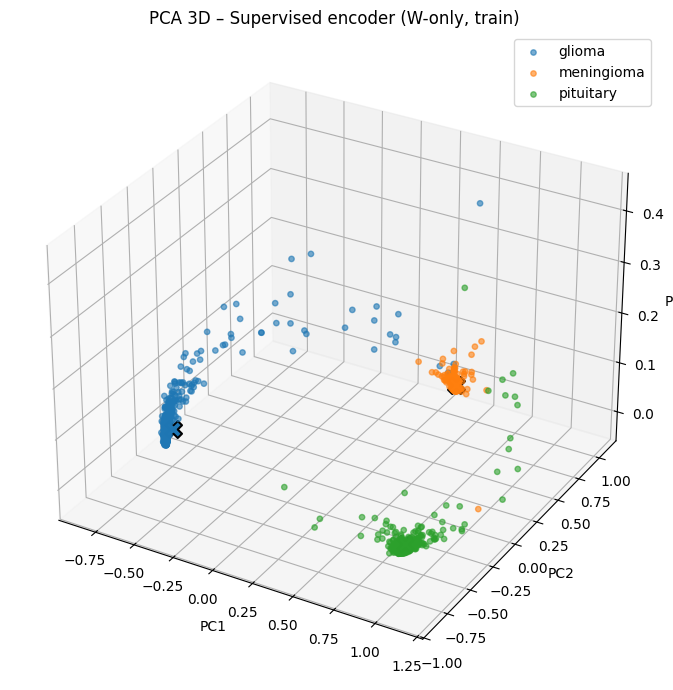

In [ ]:
pca_3d_plot(
    npz_path="/content/drive/MyDrive/TESIS/w_features/W_bank_cnn_encoder_train.npz",
    title="PCA 3D – Supervised encoder (W-only, train)"
)

Using 'Fw' as features from /content/drive/MyDrive/TESIS/w_features/W_bank_cnn_encoder_test.npz
Features shape: (911, 512)
Explained variance ratio: [0.58085585 0.4127642  0.00162473]


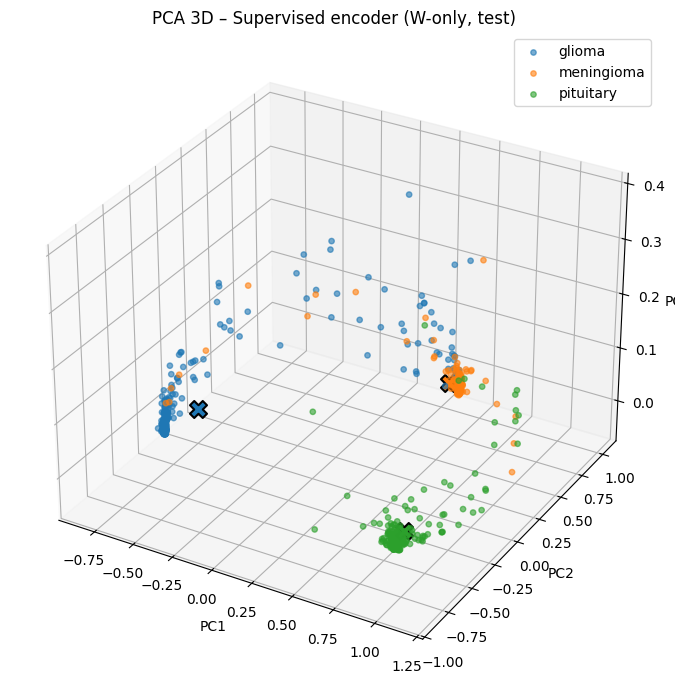

In [ ]:
pca_3d_plot(
    npz_path="/content/drive/MyDrive/TESIS/w_features/W_bank_cnn_encoder_test.npz",
    title="PCA 3D – Supervised encoder (W-only, test)"
)

Using 'Fcnn' as features from /content/drive/MyDrive/TESIS/features_cnn_resnet50_train.npz
Features shape: (2153, 2048)
Explained variance ratio: [0.36976177 0.30177006 0.05008383]


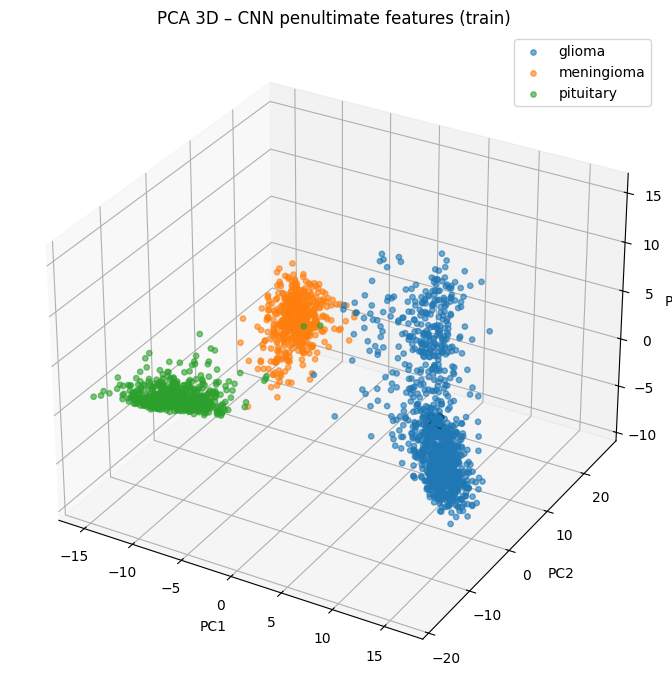

In [ ]:
pca_3d_plot(
    npz_path="/content/drive/MyDrive/TESIS/features_cnn_resnet50_train.npz",
    title="PCA 3D – CNN penultimate features (train)"
)

Using 'Fcnn' as features from /content/drive/MyDrive/TESIS/features_cnn_resnet50_test.npz
Features shape: (911, 2048)
Explained variance ratio: [0.37876374 0.26767364 0.04541158]


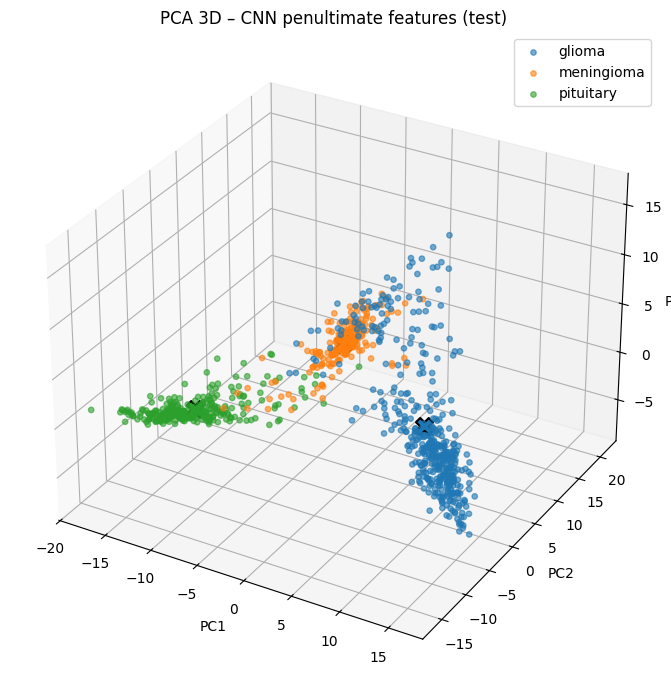

In [ ]:
pca_3d_plot(
    npz_path="/content/drive/MyDrive/TESIS/features_cnn_resnet50_test.npz",
    title="PCA 3D – CNN penultimate features (test)"
)

[INFO] Usando clave 'Fcnn' para features CNN en /content/drive/MyDrive/TESIS/features_cnn_resnet50_train.npz
[INFO] Usando clave 'Fw' para features W/encoder en /content/drive/MyDrive/TESIS/w_features/W_bank_cnn_encoder_train.npz
[INFO] Aligned 2153 common samples.
Explained var (train fusion): [0.38235945 0.2783471  0.0569002 ]
[INFO] Usando clave 'Fcnn' para features CNN en /content/drive/MyDrive/TESIS/features_cnn_resnet50_test.npz
[INFO] Usando clave 'Fw' para features W/encoder en /content/drive/MyDrive/TESIS/w_features/W_bank_cnn_encoder_test.npz
[INFO] Aligned 911 common samples.
Explained var (test fusion, approx): [0.37024882 0.24810892 0.05399034]


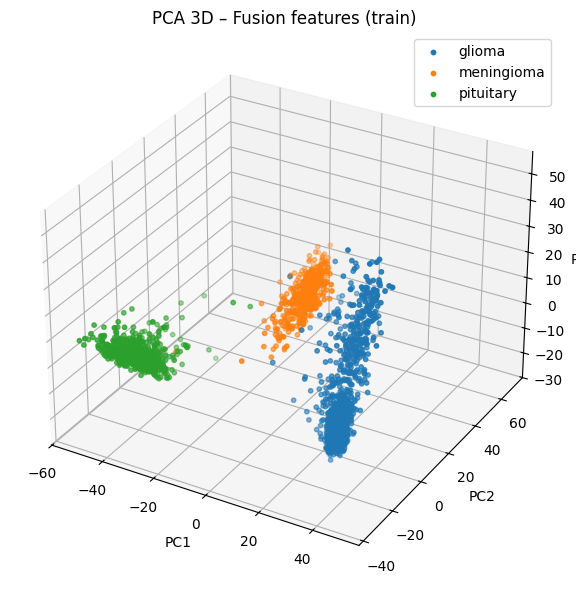

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # necesario para proyecciones 3D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Reutilizamos tus funciones (pégalas aquí o impórtalas):
# _load_cnn, _load_w, _align_by_paths

# --- Rutas a tus NPZ (ajusta a tus nombres reales) ---
cnn_npz_train = "/content/drive/MyDrive/TESIS/features_cnn_resnet50_train.npz"
w_npz_train   = "/content/drive/MyDrive/TESIS/w_features/W_bank_cnn_encoder_train.npz"

cnn_npz_test = "/content/drive/MyDrive/TESIS/features_cnn_resnet50_test.npz"
w_npz_test   = "/content/drive/MyDrive/TESIS/w_features/W_bank_cnn_encoder_test.npz"

# ---------- Cargar y fusionar (TRAIN) ----------
cnn_tr = _load_cnn(cnn_npz_train)
w_tr   = _load_w(w_npz_train)

Xcnn_tr, Xw_tr, paths_tr, y_tr, classes = _align_by_paths(cnn_tr, w_tr)
X_fusion_tr = np.concatenate([Xcnn_tr, Xw_tr], axis=1)

# Escalado (se guarda el scaler para usarlo en test)
scaler = StandardScaler()
X_fusion_tr_sc = scaler.fit_transform(X_fusion_tr)

# PCA en train
pca = PCA(n_components=3, random_state=0)
Xtr_pca = pca.fit_transform(X_fusion_tr_sc)

print("Explained var (train fusion):", pca.explained_variance_ratio_)

# ---------- Cargar y fusionar (TEST) ----------
cnn_te = _load_cnn(cnn_npz_test)
w_te   = _load_w(w_npz_test)

Xcnn_te, Xw_te, paths_te, y_te, classes_te = _align_by_paths(cnn_te, w_te)
X_fusion_te = np.concatenate([Xcnn_te, Xw_te], axis=1)

# Usamos el MISMO scaler y el MISMO PCA
X_fusion_te_sc = scaler.transform(X_fusion_te)
Xte_pca = pca.transform(X_fusion_te_sc)

# Aproximación de varianza explicada en test
var_pc_test = np.var(Xte_pca, axis=0)
var_total_test = np.sum(np.var(X_fusion_te_sc, axis=0))
explained_var_test = var_pc_test / var_total_test
print("Explained var (test fusion, approx):", explained_var_test)

# ---------- Función para plotear ----------
def plot_pca_3d(X_pca, y, classes, title):
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')

    for c in range(len(classes)):
        idx = (y == c)
        ax.scatter(
            X_pca[idx, 0],
            X_pca[idx, 1],
            X_pca[idx, 2],
            s=10,
            label=classes[c]
        )

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

# ---------- Dibujar ----------
plot_pca_3d(Xtr_pca, y_tr, classes, "PCA 3D – Fusion features (train)")

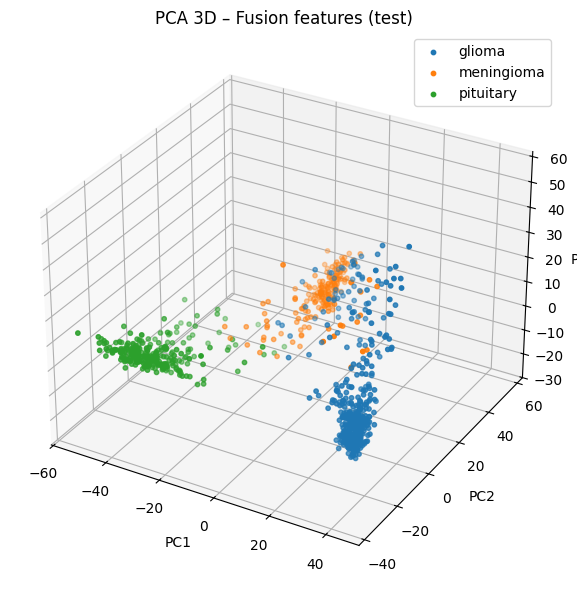

Explained var (test fusion, approx): [0.37024882 0.24810892 0.05399034]


In [ ]:
plot_pca_3d(Xte_pca, y_te, classes_te, "PCA 3D – Fusion features (test)")
print("Explained var (test fusion, approx):", explained_var_test)

#e4e

Using 'Fw' as features from /content/drive/MyDrive/StyleGan2/encodernpze4e/train2W_bank.npz
Features shape: (2153, 7168)
Explained variance ratio: [0.33473167 0.19463336 0.13366312]


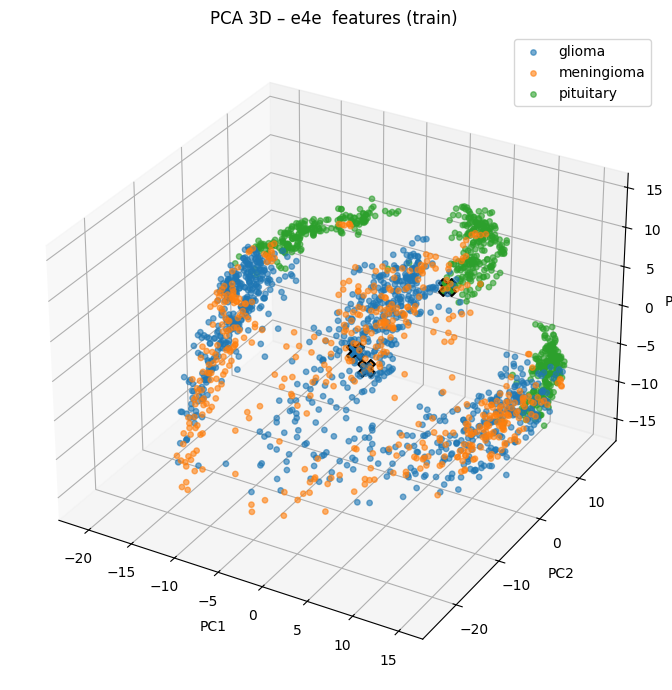

In [ ]:
pca_3d_plot(
    npz_path="/content/drive/MyDrive/StyleGan2/encodernpze4e/train2W_bank.npz",
    title="PCA 3D – e4e  features (train)"
)

Using 'Fw' as features from /content/drive/MyDrive/StyleGan2/encodernpze4e/test2W_bank.npz
Features shape: (911, 7168)
Explained variance ratio: [0.35978276 0.1779991  0.14791608]


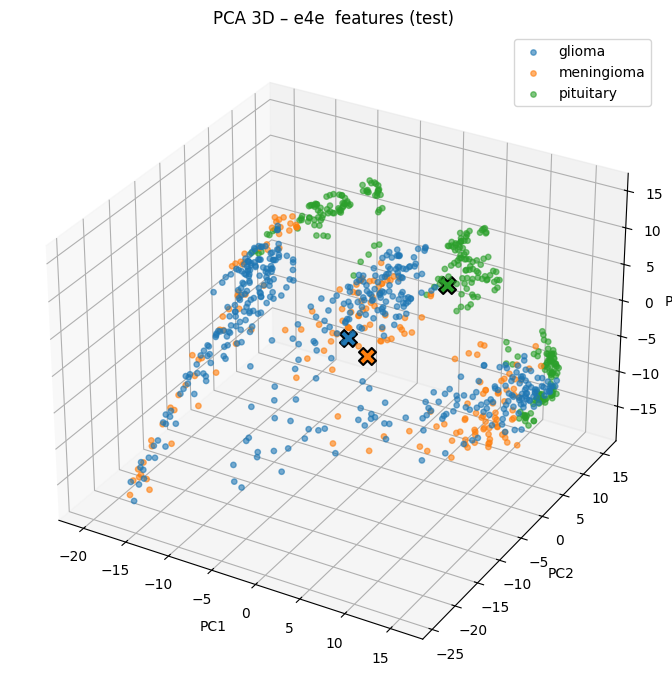

In [ ]:
pca_3d_plot(
    npz_path="/content/drive/MyDrive/StyleGan2/encodernpze4e/test2W_bank.npz",
    title="PCA 3D – e4e  features (test)"
)

# Task
Define helper functions `_load_cnn`, `_load_w`, `_align_by_paths`, and `classify_features` for loading, aligning, standardizing, training, and evaluating classification models using the generated feature NPZ files, then classify using PSP encoder W+ features.

## Load Features and Helper Functions

### Subtask:
Load features from the PSP encoder (W+), supervised CNN encoder (W), and fine-tuned ResNet50 (Fcnn) NPZ files for both training and testing datasets. This step will also define the necessary helper functions (`_load_cnn`, `_load_w`, `_align_by_paths`, and `classify_features`) to standardize, train, and evaluate a classifier.


**Reasoning**:
First, I will import all the necessary libraries for feature loading, alignment, and classification. Then, I will define the helper functions as specified in the instructions, which include functions for loading features from different NPZ structures, aligning features by image paths, and performing SVM classification with scaling and reporting.



In [ ]:
import numpy as np
import json
from pathlib import Path
from typing import Dict, Tuple
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
# Removed seaborn and matplotlib.pyplot imports as they are no longer needed for text-based confusion matrix

def _load_cnn(npz_path: str) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Loads Fcnn features, paths, labels, and classes from an NPZ file."""
    d = np.load(npz_path, allow_pickle=True)
    X = d["Fcnn"]
    y = d["y"]
    paths = d["paths"]
    classes = d["classes"]
    print(f"[INFO] Usando clave 'Fcnn' para features CNN en {npz_path}")
    return X, y, paths, classes

def _load_w(npz_path: str) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Loads Fw (W+) features, paths, labels, and classes from an NPZ file."""
    d = np.load(npz_path, allow_pickle=True)
    # Check for 'Fw' first, then 'features' as fallback
    if "Fw" in d.files:
        X = d["Fw"]
        print(f"[INFO] Usando clave 'Fw' para features W/encoder en {npz_path}")
    elif "features" in d.files:
        X = d["features"]
        print(f"[INFO] Usando clave 'features' para features W/encoder en {npz_path}")
    else:
        raise KeyError(f"No 'Fw' or 'features' key found in {npz_path}")

    y = d["y"]
    paths = d["paths"]
    classes = d["classes"]
    return X, y, paths, classes

def _align_by_paths(
    feat_dict1: Dict,
    feat_dict2: Dict,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Aligns two feature sets based on common image paths.
    Returns aligned features X1, X2, common paths, aligned y labels, and classes.
    """
    X1_all, y1_all, paths1_all, classes1 = feat_dict1
    X2_all, y2_all, paths2_all, classes2 = feat_dict2

    # Ensure both datasets have the same classes in the same order
    if not np.array_equal(classes1, classes2):
        print("[WARNING] Classes do not match between feature dictionaries. Using classes from the first dictionary.")

    # Create a mapping from path to index for faster lookup
    path1_to_idx = {path: i for i, path in enumerate(paths1_all)}
    path2_to_idx = {path: i for i, path in enumerate(paths2_all)}

    common_paths = sorted(list(set(paths1_all) & set(paths2_all)))

    # Initialize lists for aligned data
    X1_aligned, X2_aligned, y_aligned, paths_aligned = [], [], [], []

    for path in common_paths:
        idx1 = path1_to_idx[path]
        idx2 = path2_to_idx[path]

        X1_aligned.append(X1_all[idx1])
        X2_aligned.append(X2_all[idx2])
        y_aligned.append(y1_all[idx1]) # Assuming labels are consistent for common paths
        paths_aligned.append(path)

    X1_aligned = np.array(X1_aligned)
    X2_aligned = np.array(X2_aligned)
    y_aligned = np.array(y_aligned)
    paths_aligned = np.array(paths_aligned)

    print(f"[INFO] Aligned {len(common_paths)} common samples.")
    return X1_aligned, X2_aligned, paths_aligned, y_aligned, classes1

def classify_features(X_train, y_train, X_test, y_test, classes, title: str, digits: int = 2) -> float:
    """Trains and evaluates an SVC classifier on given features."""
    print(f"\n--- Classification for: {title} ---")

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train SVC
    classifier = SVC(kernel='linear', random_state=42)
    classifier.fit(X_train_scaled, y_train)

    # Predict and evaluate
    y_pred = classifier.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)

    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=classes, digits=digits))
    print(f"Accuracy Score: {accuracy:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    # Print with class labels for clarity
    cm_df = pd.DataFrame(cm, index=classes, columns=classes)
    print(cm_df)

    return accuracy


# --- Define file paths ---
psp_w_train_npz = "/content/drive/MyDrive/StyleGan2/encodernpze4e/train3W_bank.npz" # Changed to train2W_bank.npz
psp_w_test_npz = "/content/drive/MyDrive/StyleGan2/encodernpze4e/test3W_bank.npz"   # Changed to test2W_bank.npz

cnn_fcnn_train_npz = "/content/drive/MyDrive/TESIS/features_cnn_resnet50_train.npz"
cnn_fcnn_test_npz = "/content/drive/MyDrive/TESIS/features_cnn_resnet50_test.npz"

sup_w_train_npz = "/content/drive/MyDrive/TESIS/w_features/W_bank_cnn_encoder_train.npz"
sup_w_test_npz = "/content/drive/MyDrive/TESIS/w_features/W_bank_cnn_encoder_test.npz"


# --- Load features ---
print("\n--- Loading Features ---")
psp_w_train_data = _load_w(psp_w_train_npz)
psp_w_test_data = _load_w(psp_w_test_npz)

cnn_fcnn_train_data = _load_cnn(cnn_fcnn_train_npz)
cnn_fcnn_test_data = _load_cnn(cnn_fcnn_test_npz)

sup_w_train_data = _load_w(sup_w_train_npz)
sup_w_test_data = _load_w(sup_w_test_npz)

print("All features and helper functions loaded successfully.")


--- Loading Features ---
[INFO] Usando clave 'Fw' para features W/encoder en /content/drive/MyDrive/StyleGan2/encodernpze4e/train3W_bank.npz
[INFO] Usando clave 'Fw' para features W/encoder en /content/drive/MyDrive/StyleGan2/encodernpze4e/test3W_bank.npz
[INFO] Usando clave 'Fcnn' para features CNN en /content/drive/MyDrive/TESIS/features_cnn_resnet50_train.npz
[INFO] Usando clave 'Fcnn' para features CNN en /content/drive/MyDrive/TESIS/features_cnn_resnet50_test.npz
[INFO] Usando clave 'Fw' para features W/encoder en /content/drive/MyDrive/TESIS/w_features/W_bank_cnn_encoder_train.npz
[INFO] Usando clave 'Fw' para features W/encoder en /content/drive/MyDrive/TESIS/w_features/W_bank_cnn_encoder_test.npz
All features and helper functions loaded successfully.


In [ ]:
print("\n--- Dimensions of Feature NPZ Files ---")

# PSP W+ Features
X, _, _, _ = _load_w(psp_w_train_npz)
print(f"PSP W+ Train features dimension: {X.shape}")
X, _, _, _ = _load_w(psp_w_test_npz)
print(f"PSP W+ Test features dimension: {X.shape}")

# CNN Fcnn Features
X, _, _, _ = _load_cnn(cnn_fcnn_train_npz)
print(f"ResNet50 Fcnn Train features dimension: {X.shape}")
X, _, _, _ = _load_cnn(cnn_fcnn_test_npz)
print(f"ResNet50 Fcnn Test features dimension: {X.shape}")

# Supervised CNN Encoder W Features
X, _, _, _ = _load_w(sup_w_train_npz)
print(f"Supervised CNN W Train features dimension: {X.shape}")
X, _, _, _ = _load_w(sup_w_test_npz)
print(f"Supervised CNN W Test features dimension: {X.shape}")


--- Dimensions of Feature NPZ Files ---
[INFO] Usando clave 'Fw' para features W/encoder en /content/drive/MyDrive/StyleGan2/encodernpze4e/train3W_bank.npz
PSP W+ Train features dimension: (2153, 7168)
[INFO] Usando clave 'Fw' para features W/encoder en /content/drive/MyDrive/StyleGan2/encodernpze4e/test3W_bank.npz
PSP W+ Test features dimension: (911, 7168)
[INFO] Usando clave 'Fcnn' para features CNN en /content/drive/MyDrive/TESIS/features_cnn_resnet50_train.npz
ResNet50 Fcnn Train features dimension: (2153, 2048)
[INFO] Usando clave 'Fcnn' para features CNN en /content/drive/MyDrive/TESIS/features_cnn_resnet50_test.npz
ResNet50 Fcnn Test features dimension: (911, 2048)
[INFO] Usando clave 'Fw' para features W/encoder en /content/drive/MyDrive/TESIS/w_features/W_bank_cnn_encoder_train.npz
Supervised CNN W Train features dimension: (2153, 512)
[INFO] Usando clave 'Fw' para features W/encoder en /content/drive/MyDrive/TESIS/w_features/W_bank_cnn_encoder_test.npz
Supervised CNN W Test

## Classify with PSP Encoder W+ Features

### Subtask:
Perform classification using only the PSP encoder W+ features, including standardization, training an SVM classifier, and evaluating its performance.


**Reasoning**:
Extracting the W+ features, labels, and class names from the pre-loaded `psp_w_train_data` and `psp_w_test_data` for classification.



In [ ]:
X_train_psp_w, y_train_psp_w, _, classes_psp_w = psp_w_train_data
X_test_psp_w, y_test_psp_w, _, _ = psp_w_test_data

# Perform classification using only PSP encoder W+ features
accuracy_psp_w = classify_features(
    X_train_psp_w,
    y_train_psp_w,
    X_test_psp_w,
    y_test_psp_w,
    classes_psp_w,
    "PSP Encoder W+ Features"
)
print(f"PSP Encoder W+ Features Accuracy: {accuracy_psp_w:.4f}")


--- Classification for: PSP Encoder W+ Features ---
Classification Report:
              precision    recall  f1-score   support

      glioma       0.89      0.86      0.87       446
  meningioma       0.63      0.72      0.67       194
   pituitary       0.93      0.89      0.91       271

    accuracy                           0.84       911
   macro avg       0.82      0.82      0.82       911
weighted avg       0.85      0.84      0.84       911

Accuracy Score: 0.8386

Confusion Matrix:
            glioma  meningioma  pituitary
glioma         384          56          6
meningioma      42         140         12
pituitary        6          25        240
PSP Encoder W+ Features Accuracy: 0.8386


In [ ]:
X_train_psp_w, y_train_psp_w, _, classes_psp_w = psp_w_train_data
X_test_psp_w, y_test_psp_w, _, _ = psp_w_test_data

# Perform classification using only PSP encoder W+ features
accuracy_psp_w = classify_features(
    X_train_psp_w,
    y_train_psp_w,
    X_test_psp_w,
    y_test_psp_w,
    classes_psp_w,
    "PSP Encoder W+ Features",
    digits=3 # Added digits argument
)
print(f"PSP Encoder W+ Features Accuracy: {accuracy_psp_w:.4f}")


--- Classification for: PSP Encoder W+ Features ---
Classification Report:
              precision    recall  f1-score   support

      glioma      0.889     0.861     0.875       446
  meningioma      0.633     0.722     0.675       194
   pituitary      0.930     0.886     0.907       271

    accuracy                          0.839       911
   macro avg      0.818     0.823     0.819       911
weighted avg      0.847     0.839     0.842       911

Accuracy Score: 0.8386

Confusion Matrix:
            glioma  meningioma  pituitary
glioma         384          56          6
meningioma      42         140         12
pituitary        6          25        240
PSP Encoder W+ Features Accuracy: 0.8386


## Classify with Supervised CNN Encoder W Features

### Subtask:
Perform classification using only the supervised CNN encoder W features, including standardization, training an SVM classifier, and evaluating its performance.


## Classify with Supervised CNN Encoder W Features

### Subtask:
Perform classification using only the supervised CNN encoder W features, including standardization, training an SVM classifier, and evaluating its performance.


**Reasoning**:
Next, I will extract the features, labels, and class names from the previously loaded `sup_w_train_data` and `sup_w_test_data` variables. Then, I will call the `classify_features` function with these extracted training and testing features, labels, and classes, and print the returned accuracy score.



In [ ]:
X_train_sup_w, y_train_sup_w, _, classes_sup_w = sup_w_train_data
X_test_sup_w, y_test_sup_w, _, _ = sup_w_test_data

# Perform classification using only Supervised CNN Encoder W features
accuracy_sup_w = classify_features(
    X_train_sup_w,
    y_train_sup_w,
    X_test_sup_w,
    y_test_sup_w,
    classes_sup_w,
    "Supervised CNN Encoder W Features",
    digits=3 # Added digits argument
)
print(f"Supervised CNN Encoder W Features Accuracy: {accuracy_sup_w:.4f}")


--- Classification for: Supervised CNN Encoder W Features ---
Classification Report:
              precision    recall  f1-score   support

      glioma      0.970     0.948     0.959       446
  meningioma      0.851     0.912     0.881       194
   pituitary      0.985     0.970     0.978       271

    accuracy                          0.947       911
   macro avg      0.935     0.944     0.939       911
weighted avg      0.949     0.947     0.948       911

Accuracy Score: 0.9473

Confusion Matrix:
            glioma  meningioma  pituitary
glioma         423          23          0
meningioma      13         177          4
pituitary        0           8        263
Supervised CNN Encoder W Features Accuracy: 0.9473


## Classify with ResNet50 Fcnn Features

### Subtask:
Perform classification using only the fine-tuned ResNet50 Fcnn features, including standardization, training an SVM classifier, and evaluating its performance.


**Reasoning**:
I will extract the features, labels, and class names from the previously loaded `cnn_fcnn_train_data` and `cnn_fcnn_test_data` variables. Then, I will call the `classify_features` function with these extracted training and testing features, labels, and classes, and print the returned accuracy score.



In [ ]:
X_train_cnn_fcnn, y_train_cnn_fcnn, _, classes_cnn_fcnn = cnn_fcnn_train_data
X_test_cnn_fcnn, y_test_cnn_fcnn, _, _ = cnn_fcnn_test_data

# Perform classification using only ResNet50 Fcnn features
accuracy_cnn_fcnn = classify_features(
    X_train_cnn_fcnn,
    y_train_cnn_fcnn,
    X_test_cnn_fcnn,
    y_test_cnn_fcnn,
    classes_cnn_fcnn,
    "ResNet50 Fcnn Features",
    digits=3 # Added digits argument
)
print(f"ResNet50 Fcnn Features Accuracy: {accuracy_cnn_fcnn:.4f}")


--- Classification for: ResNet50 Fcnn Features ---
Classification Report:
              precision    recall  f1-score   support

      glioma      0.961     0.939     0.950       446
  meningioma      0.847     0.887     0.866       194
   pituitary      0.967     0.970     0.969       271

    accuracy                          0.937       911
   macro avg      0.925     0.932     0.928       911
weighted avg      0.939     0.937     0.938       911

Accuracy Score: 0.9374

Confusion Matrix:
            glioma  meningioma  pituitary
glioma         419          24          3
meningioma      16         172          6
pituitary        1           7        263
ResNet50 Fcnn Features Accuracy: 0.9374


## Prepare and Classify with Fusion Features

### Subtask:
Concatenate the aligned features from all three models to create a combined feature set (fusion). Then, perform classification using these fusion features, including standardization, training an SVM classifier, and evaluating its performance.


**Reasoning**:
To classify with fusion features, I need to align the features from all three models (PSP W+, CNN Fcnn, and supervised CNN W) for both the training and testing sets based on common image paths. I will use a helper function to perform this alignment and concatenation, then call the `classify_features` function.



In [ ]:
def _align_multiple_by_paths(
    feature_data_list: list[Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]],
) -> Tuple[list[np.ndarray], np.ndarray, np.ndarray]:
    """
    Aligns multiple feature sets based on common image paths.
    Returns a list of aligned feature arrays, a single aligned y labels array,
    and the common classes.
    """
    if not feature_data_list:
        raise ValueError("feature_data_list cannot be empty.")

    # Get all paths from each dataset
    all_paths_sets = [set(data[2]) for data in feature_data_list] # data[2] is paths

    # Find the intersection of all paths
    common_paths_set = all_paths_sets[0]
    for paths_set in all_paths_sets[1:]:
        common_paths_set &= paths_set

    common_paths = sorted(list(common_paths_set))
    if not common_paths:
        raise ValueError("No common paths found among the feature sets.")

    print(f"[INFO] Aligned {len(common_paths)} common samples across multiple feature sets.")

    aligned_X_list = []
    aligned_y = None
    common_classes = feature_data_list[0][3] # Assuming classes are consistent across datasets

    for X_orig, y_orig, paths_orig, _ in feature_data_list:
        path_to_idx = {path: i for i, path in enumerate(paths_orig)}
        current_X_aligned = []
        current_y_aligned = []

        for path in common_paths:
            idx = path_to_idx[path]
            current_X_aligned.append(X_orig[idx])
            current_y_aligned.append(y_orig[idx])

        aligned_X_list.append(np.array(current_X_aligned))

        if aligned_y is None:
            aligned_y = np.array(current_y_aligned)
        else:
            # Optional: Add a check if labels are consistent for common paths
            # if not np.array_equal(aligned_y, np.array(current_y_aligned)):
            #     print("[WARNING] Labels for common paths are not consistent. Using labels from the first set.")
            pass # Assuming labels are consistent for common paths

    return aligned_X_list, aligned_y, common_classes


# --- Fusion and Classification ---

# 1. Extract and prepare lists for alignment
# Training data
train_feature_data_list = [
    psp_w_train_data,
    cnn_fcnn_train_data,
    sup_w_train_data
]

# Testing data
test_feature_data_list = [
    psp_w_test_data,
    cnn_fcnn_test_data,
    sup_w_test_data
]

# 2. Align features for training and concatenate
print("\n--- Aligning and Fusing Training Features ---")
aligned_train_X_list, y_train_fusion, classes_fusion = _align_multiple_by_paths(train_feature_data_list)
X_train_fusion = np.concatenate(aligned_train_X_list, axis=1)
print(f"X_train_fusion shape: {X_train_fusion.shape}")
print(f"y_train_fusion shape: {y_train_fusion.shape}")

# 2. Align features for testing and concatenate
print("\n--- Aligning and Fusing Testing Features ---")
aligned_test_X_list, y_test_fusion, _ = _align_multiple_by_paths(test_feature_data_list)
X_test_fusion = np.concatenate(aligned_test_X_list, axis=1)
print(f"X_test_fusion shape: {X_test_fusion.shape}")
print(f"y_test_fusion shape: {y_test_fusion.shape}")


# 3. Call classify_features function
accuracy_fusion = classify_features(
    X_train_fusion,
    y_train_fusion,
    X_test_fusion,
    y_test_fusion,
    classes_fusion,
    "Fusion Features",
    digits=3 # Added digits argument
)

# 4. Print the returned accuracy score for the fusion features.
print(f"Fusion Features Accuracy: {accuracy_fusion:.4f}")


--- Aligning and Fusing Training Features ---
[INFO] Aligned 2153 common samples across multiple feature sets.
X_train_fusion shape: (2153, 9728)
y_train_fusion shape: (2153,)

--- Aligning and Fusing Testing Features ---
[INFO] Aligned 911 common samples across multiple feature sets.
X_test_fusion shape: (911, 9728)
y_test_fusion shape: (911,)

--- Classification for: Fusion Features ---
Classification Report:
              precision    recall  f1-score   support

      glioma      0.967     0.930     0.949       446
  meningioma      0.838     0.907     0.871       194
   pituitary      0.982     0.985     0.983       271

    accuracy                          0.942       911
   macro avg      0.929     0.941     0.934       911
weighted avg      0.944     0.942     0.942       911

Accuracy Score: 0.9418

Confusion Matrix:
            glioma  meningioma  pituitary
glioma         415          31          0
meningioma      13         176          5
pituitary        1           3     

## Final Task

### Subtask:
Summarize and compare the classification results from all individual and fused feature sets.


In [ ]:
import numpy as np
import json
from pathlib import Path
from typing import Dict, Tuple
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Removed seaborn and matplotlib.pyplot imports as they are no longer needed for text-based confusion matrix

def _load_cnn(npz_path: str) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Loads Fcnn features, paths, labels, and classes from an NPZ file."""
    d = np.load(npz_path, allow_pickle=True)
    X = d["Fcnn"]
    y = d["y"]
    paths = d["paths"]
    classes = d["classes"]
    print(f"[INFO] Using key 'Fcnn' for CNN features in {npz_path}")
    return X, y, paths, classes

def _load_w(npz_path: str) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Loads W-space features, paths, labels, and classes from an NPZ file."""
    d = np.load(npz_path, allow_pickle=True)
    # Check for 'Fw' first, then 'features' as fallback
    if "Fw" in d.files:
        X = d["Fw"]
        print(f"[INFO] Using key 'Fw' for W/encoder features in {npz_path}")
    elif "features" in d.files:
        X = d["features"]
        print(f"[INFO] Using key 'features' for W/encoder features in {npz_path}")
    else:
        raise KeyError(f"No 'Fw' or 'features' key found in {npz_path}")

    y = d["y"]
    paths = d["paths"]
    classes = d["classes"]
    return X, y, paths, classes

def _align_by_paths(
    feat_dict1: Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray],
    feat_dict2: Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray],
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Aligns two feature sets based on common image paths.
    Returns aligned features X1, X2, common paths, aligned y labels, and classes.
    """
    X1_all, y1_all, paths1_all, classes1 = feat_dict1
    X2_all, y2_all, paths2_all, classes2 = feat_dict2

    # Ensure both datasets have the same classes in the same order
    if not np.array_equal(classes1, classes2):
        print("[WARNING] Classes do not match between feature dictionaries. "
              "Using classes from the first dictionary.")

    # Create a mapping from path to index for faster lookup
    path1_to_idx = {path: i for i, path in enumerate(paths1_all)}
    path2_to_idx = {path: i for i, path in enumerate(paths2_all)}

    common_paths = sorted(list(set(paths1_all) & set(paths2_all)))

    # Initialize lists for aligned data
    X1_aligned, X2_aligned, y_aligned, paths_aligned = [], [], [], []

    for path in common_paths:
        idx1 = path1_to_idx[path]
        idx2 = path2_to_idx[path]

        X1_aligned.append(X1_all[idx1])
        X2_aligned.append(X2_all[idx2])
        # Assuming labels are consistent for common paths
        y_aligned.append(y1_all[idx1])
        paths_aligned.append(path)

    X1_aligned = np.array(X1_aligned)
    X2_aligned = np.array(X2_aligned)
    y_aligned = np.array(y_aligned)
    paths_aligned = np.array(paths_aligned)

    print(f"[INFO] Aligned {len(common_paths)} common samples.")
    return X1_aligned, X2_aligned, paths_aligned, y_aligned, classes1

def classify_features(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    classes: np.ndarray,
    title: str,
    digits: int = 2,
) -> float:
    """Trains and evaluates a linear SVC classifier on given features."""
    print(f"\n--- Classification for: {title} (no PCA) ---")

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train SVC
    classifier = SVC(kernel='linear', random_state=42)
    classifier.fit(X_train_scaled, y_train)

    # Predict and evaluate
    y_pred = classifier.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)

    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=classes, digits=digits))
    print(f"Accuracy Score: {accuracy:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    cm_df = pd.DataFrame(cm, index=classes, columns=classes)
    print(cm_df)

    return accuracy

def classify_features_with_pca(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    classes: np.ndarray,
    title: str,
    n_components: int = 128,
    digits: int = 2,
) -> float:
    """
    Trains and evaluates a linear SVC classifier on PCA-reduced features.

    Pipeline:
        1) StandardScaler
        2) PCA(n_components)
        3) Linear SVM
    """
    print(f"\n--- Classification for: {title} (PCA -> {n_components} dims) ---")

    # Standardize
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # PCA
    pca = PCA(n_components=n_components, random_state=42)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    explained_sum = pca.explained_variance_ratio_.sum()
    print(f"[INFO] PCA({n_components}) explains {explained_sum:.4f} of the variance.")

    # Train SVC on PCA features
    classifier = SVC(kernel='linear', random_state=42)
    classifier.fit(X_train_pca, y_train)

    # Predict and evaluate
    y_pred = classifier.predict(X_test_pca)
    accuracy = accuracy_score(y_test, y_pred)

    print("Classification Report (PCA):")
    print(classification_report(y_test, y_pred, target_names=classes, digits=digits))
    print(f"Accuracy Score (PCA): {accuracy:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix (PCA):")
    cm_df = pd.DataFrame(cm, index=classes, columns=classes)
    print(cm_df)

    return accuracy

# --- Define file paths ---
psp_w_train_npz = "/content/drive/MyDrive/StyleGan2/encodernpze4e/train2W_bank.npz"
psp_w_test_npz  = "/content/drive/MyDrive/StyleGan2/encodernpze4e/test2W_bank.npz"

cnn_fcnn_train_npz = "/content/drive/MyDrive/TESIS/features_cnn_resnet50_train.npz"
cnn_fcnn_test_npz  = "/content/drive/MyDrive/TESIS/features_cnn_resnet50_test.npz"

sup_w_train_npz = "/content/drive/MyDrive/TESIS/w_features/W_bank_cnn_encoder_train.npz"
sup_w_test_npz  = "/content/drive/MyDrive/TESIS/w_features/W_bank_cnn_encoder_test.npz"

if __name__ == "__main__":
    print("\n--- Loading Features ---")
    # pSp / e4e W-space
    psp_w_train_data = _load_w(psp_w_train_npz)
    psp_w_test_data  = _load_w(psp_w_test_npz)

    # CNN features
    cnn_fcnn_train_data = _load_cnn(cnn_fcnn_train_npz)
    cnn_fcnn_test_data  = _load_cnn(cnn_fcnn_test_npz)

    # Supervised W encoder
    sup_w_train_data = _load_w(sup_w_train_npz)
    sup_w_test_data  = _load_w(sup_w_test_npz)

    print("All features and helper functions loaded successfully.")

    # ----- Unpack each feature set -----
    X_train_cnn, y_train_cnn, paths_train_cnn, classes_cnn = cnn_fcnn_train_data
    X_test_cnn,  y_test_cnn,  paths_test_cnn,  _          = cnn_fcnn_test_data

    X_train_psp, y_train_psp, paths_train_psp, classes_psp = psp_w_train_data
    X_test_psp,  y_test_psp,  paths_test_psp,  _          = psp_w_test_data

    X_train_sup, y_train_sup, paths_train_sup, classes_sup = sup_w_train_data
    X_test_sup,  y_test_sup,  paths_test_sup,  _          = sup_w_test_data

    # Sanity check: you can assert classes coincide if needed
    # assert np.array_equal(classes_cnn, classes_psp)
    # assert np.array_equal(classes_cnn, classes_sup)

    # ----- CNN-only with PCA(128) -----
    acc_cnn_pca = classify_features_with_pca(
        X_train_cnn, y_train_cnn,
        X_test_cnn,  y_test_cnn,
        classes_cnn,
        title="CNN-only + PCA-128",
        n_components=128,
    )

    # ----- pSp / e4e W-only with PCA(128) -----
    acc_psp_pca = classify_features_with_pca(
        X_train_psp, y_train_psp,
        X_test_psp,  y_test_psp,
        classes_psp,
        title="pSp/e4e W-only + PCA-128",
        n_components=128,
    )

    # ----- Supervised W-only with PCA(128) -----
    acc_sup_pca = classify_features_with_pca(
        X_train_sup, y_train_sup,
        X_test_sup,  y_test_sup,
        classes_sup,
        title="Supervised W-only + PCA-128",
        n_components=128,
    )

    print("\n=== Summary (PCA-128) ===")
    print(f"CNN-only       (PCA-128) Accuracy: {acc_cnn_pca:.4f}")
    print(f"pSp/e4e W-only (PCA-128) Accuracy: {acc_psp_pca:.4f}")
    print(f"SupW-only      (PCA-128) Accuracy: {acc_sup_pca:.4f}")


--- Loading Features ---
[INFO] Using key 'Fw' for W/encoder features in /content/drive/MyDrive/StyleGan2/encodernpze4e/train2W_bank.npz
[INFO] Using key 'Fw' for W/encoder features in /content/drive/MyDrive/StyleGan2/encodernpze4e/test2W_bank.npz
[INFO] Using key 'Fcnn' for CNN features in /content/drive/MyDrive/TESIS/features_cnn_resnet50_train.npz
[INFO] Using key 'Fcnn' for CNN features in /content/drive/MyDrive/TESIS/features_cnn_resnet50_test.npz
[INFO] Using key 'Fw' for W/encoder features in /content/drive/MyDrive/TESIS/w_features/W_bank_cnn_encoder_train.npz
[INFO] Using key 'Fw' for W/encoder features in /content/drive/MyDrive/TESIS/w_features/W_bank_cnn_encoder_test.npz
All features and helper functions loaded successfully.

--- Classification for: CNN-only + PCA-128 (PCA -> 128 dims) ---
[INFO] PCA(128) explains 0.9031 of the variance.
Classification Report (PCA):
              precision    recall  f1-score   support

      glioma       0.96      0.94      0.95       446
 

In [ ]:
import numpy as np
from pathlib import Path
from typing import Tuple
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# ============================================================
# Feature loading helpers
# ============================================================

def _load_cnn(npz_path: str) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Loads CNN features, paths, labels, and classes from an NPZ file.
    Expects keys: 'Fcnn', 'y', 'paths', 'classes'.
    """
    d = np.load(npz_path, allow_pickle=True)
    X = d["Fcnn"]
    y = d["y"]
    paths = d["paths"]
    classes = d["classes"]
    print(f"[INFO] Using key 'Fcnn' for CNN features in {npz_path}")
    return X, y, paths, classes


def _load_w(npz_path: str) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Loads W/encoder features, paths, labels, and classes from an NPZ file.
    Tries 'Fw' first, then 'features'.
    """
    d = np.load(npz_path, allow_pickle=True)

    if "Fw" in d.files:
        X = d["Fw"]
        print(f"[INFO] Using key 'Fw' for W/encoder features in {npz_path}")
    elif "features" in d.files:
        X = d["features"]
        print(f"[INFO] Using key 'features' for W/encoder features in {npz_path}")
    else:
        raise KeyError(f"No 'Fw' or 'features' key found in {npz_path}")

    y = d["y"]
    paths = d["paths"]
    classes = d["classes"]
    return X, y, paths, classes


def _align_by_paths(
    feat_dict1: Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray],
    feat_dict2: Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray],
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Aligns two feature sets based on common image paths.
    Returns aligned features X1, X2, common paths, aligned y labels, and classes.
    """
    X1_all, y1_all, paths1_all, classes1 = feat_dict1
    X2_all, y2_all, paths2_all, classes2 = feat_dict2

    if not np.array_equal(classes1, classes2):
        print("[WARNING] Classes do not match between feature dictionaries. "
              "Using classes from the first dictionary.")

    path1_to_idx = {p: i for i, p in enumerate(paths1_all)}
    path2_to_idx = {p: i for i, p in enumerate(paths2_all)}

    common_paths = sorted(list(set(paths1_all) & set(paths2_all)))

    X1_aligned, X2_aligned, y_aligned, paths_aligned = [], [], [], []

    for path in common_paths:
        i1 = path1_to_idx[path]
        i2 = path2_to_idx[path]
        X1_aligned.append(X1_all[i1])
        X2_aligned.append(X2_all[i2])
        y_aligned.append(y1_all[i1])
        paths_aligned.append(path)

    X1_aligned = np.array(X1_aligned)
    X2_aligned = np.array(X2_aligned)
    y_aligned = np.array(y_aligned)
    paths_aligned = np.array(paths_aligned)

    print(f"[INFO] Aligned {len(common_paths)} common samples.")
    return X1_aligned, X2_aligned, paths_aligned, y_aligned, classes1


def _align_three_by_paths(
    feat_a: Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray],
    feat_b: Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray],
    feat_c: Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray],
):
    """
    Aligns three feature sets (e.g. CNN, SupW, PSP) based on common image paths.
    Returns:
        X_a, X_b, X_c, paths, y, classes
    """
    Xa, ya, pa, classes_a = feat_a
    Xb, yb, pb, classes_b = feat_b
    Xc, yc, pc, classes_c = feat_c

    # Optional: check classes consistency
    if not (np.array_equal(classes_a, classes_b) and np.array_equal(classes_a, classes_c)):
        print("[WARNING] Class arrays differ across feature sets. Using classes from the first one.")

    path_to_idx_a = {p: i for i, p in enumerate(pa)}
    path_to_idx_b = {p: i for i, p in enumerate(pb)}
    path_to_idx_c = {p: i for i, p in enumerate(pc)}

    common_paths = sorted(list(set(pa) & set(pb) & set(pc)))

    X_a_aligned, X_b_aligned, X_c_aligned = [], [], []
    y_aligned, paths_aligned = [], []

    for path in common_paths:
        ia = path_to_idx_a[path]
        ib = path_to_idx_b[path]
        ic = path_to_idx_c[path]

        X_a_aligned.append(Xa[ia])
        X_b_aligned.append(Xb[ib])
        X_c_aligned.append(Xc[ic])
        y_aligned.append(ya[ia])
        paths_aligned.append(path)

    X_a_aligned = np.array(X_a_aligned)
    X_b_aligned = np.array(X_b_aligned)
    X_c_aligned = np.array(X_c_aligned)
    y_aligned = np.array(y_aligned)
    paths_aligned = np.array(paths_aligned)

    print(f"[INFO] Aligned {len(common_paths)} common samples across three feature sets.")
    return X_a_aligned, X_b_aligned, X_c_aligned, paths_aligned, y_aligned, classes_a


# ============================================================
# Classification helpers
# ============================================================

def classify_svm_linear(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    classes: np.ndarray,
    title: str,
    digits: int = 2,
    prob: bool = False,
):
    """
    Trains and evaluates a linear SVM on given features.
    Returns: (accuracy, fitted_scaler, fitted_classifier)
    """
    print(f"\n--- Classification for: {title} ---")

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    clf = SVC(kernel="linear", probability=prob, random_state=42)
    clf.fit(X_train_scaled, y_train)

    y_pred = clf.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)

    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=classes, digits=digits))
    print(f"Accuracy Score: {acc:.4f}")

    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    print(pd.DataFrame(cm, index=classes, columns=classes))

    return acc, scaler, clf


def classify_mlp(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    classes: np.ndarray,
    title: str,
    hidden_dim: int = 256,
    digits: int = 2,
):
    """
    Trains and evaluates a small MLP classifier on given features.
    """
    print(f"\n--- Classification for: {title} (MLP) ---")

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    mlp = MLPClassifier(
        hidden_layer_sizes=(hidden_dim,),
        activation="relu",
        solver="adam",
        max_iter=200,
        random_state=42,
    )
    mlp.fit(X_train_scaled, y_train)

    y_pred = mlp.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)

    print("Classification Report (MLP):")
    print(classification_report(y_test, y_pred, target_names=classes, digits=digits))
    print(f"Accuracy Score (MLP): {acc:.4f}")

    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix (MLP):")
    print(pd.DataFrame(cm, index=classes, columns=classes))

    return acc, scaler, mlp


def score_fusion(
    X_test_cnn: np.ndarray,
    X_test_sup: np.ndarray,
    X_test_psp: np.ndarray,
    y_test: np.ndarray,
    classes: np.ndarray,
    scaler_cnn: StandardScaler,
    scaler_sup: StandardScaler,
    scaler_psp: StandardScaler,
    clf_cnn: SVC,
    clf_sup: SVC,
    clf_psp: SVC,
    w_cnn: float = 0.5,
    w_sup: float = 0.4,
    w_psp: float = 0.1,
    digits: int = 2,
):
    """
    Score-level fusion of three SVMs using weighted average of probabilities.
    """

    print("\n--- Score-level Fusion (probability-weighted) ---")

    # Scale test data with respective scalers
    Xc = scaler_cnn.transform(X_test_cnn)
    Xs = scaler_sup.transform(X_test_sup)
    Xp = scaler_psp.transform(X_test_psp)

    # Get probabilities from each classifier
    Pc = clf_cnn.predict_proba(Xc)  # [N, C]
    Ps = clf_sup.predict_proba(Xs)
    Pp = clf_psp.predict_proba(Xp)

    # Weighted sum of probabilities
    fused_scores = w_cnn * Pc + w_sup * Ps + w_psp * Pp

    # Normalise just in case (should already sum to 1 if weights sum to 1)
    fused_scores = fused_scores / fused_scores.sum(axis=1, keepdims=True)

    # Change: Ensure y_pred_fused is numerical to match y_test
    y_pred_fused = fused_scores.argmax(axis=1)

    acc = accuracy_score(y_test, y_pred_fused)

    print("Classification Report (Score Fusion):")
    print(classification_report(y_test, y_pred_fused, target_names=classes, digits=digits))
    print(f"Accuracy Score (Score Fusion): {acc:.4f}")

    cm = confusion_matrix(y_test, y_pred_fused)
    print("\nConfusion Matrix (Score Fusion):")
    print(pd.DataFrame(cm, index=classes, columns=classes))

    return acc


# ============================================================
# Paths (edit if needed)
# ============================================================

psp_w_train_npz = "/content/drive/MyDrive/StyleGan2/encodernpze4e/train2W_bank.npz"
psp_w_test_npz  = "/content/drive/MyDrive/StyleGan2/encodernpze4e/test2W_bank.npz"

cnn_fcnn_train_npz = "/content/drive/MyDrive/TESIS/features_cnn_resnet50_train.npz"
cnn_fcnn_test_npz  = "/content/drive/MyDrive/TESIS/features_cnn_resnet50_test.npz"

sup_w_train_npz = "/content/drive/MyDrive/TESIS/w_features/W_bank_cnn_encoder_train.npz"
sup_w_test_npz  = "/content/drive/MyDrive/TESIS/w_features/W_bank_cnn_encoder_test.npz"


# ============================================================
# Main
# ============================================================

if __name__ == "__main__":
    print("\n--- Loading Features ---")

    # pSp / e4e W-space
    psp_w_train_data = _load_w(psp_w_train_npz)
    psp_w_test_data  = _load_w(psp_w_test_npz)

    # CNN features
    cnn_fcnn_train_data = _load_cnn(cnn_fcnn_train_npz)
    cnn_fcnn_test_data  = _load_cnn(cnn_fcnn_test_npz)

    # Supervised W encoder
    sup_w_train_data = _load_w(sup_w_train_npz)
    sup_w_test_data  = _load_w(sup_w_test_npz)

    print("All features loaded successfully.")

    # Unpack
    X_train_cnn, y_train_cnn, paths_train_cnn, classes_cnn = cnn_fcnn_train_data
    X_test_cnn,  y_test_cnn,  paths_test_cnn,  _          = cnn_fcnn_test_data

    X_train_psp, y_train_psp, paths_train_psp, classes_psp = psp_w_train_data
    X_test_psp,  y_test_psp,  paths_test_psp,  _          = psp_w_test_data

    X_train_sup, y_train_sup, paths_train_sup, classes_sup = sup_w_train_data
    X_test_sup,  y_test_sup,  paths_test_sup,  _          = sup_w_test_data

    # Sanity: classes should match
    classes = classes_cnn
    print(f"\n[INFO] Classes: {classes}")

    # --------------------------------------------------------
    # 1) Train SVMs individually (CNN, SupW, PSP) with prob=True
    # --------------------------------------------------------
    acc_cnn, scaler_cnn, clf_cnn = classify_svm_linear(
        X_train_cnn, y_train_cnn,
        X_test_cnn,  y_test_cnn,
        classes,
        title="CNN-only (Fcnn)",
        prob=True,
    )

    acc_sup, scaler_sup, clf_sup = classify_svm_linear(
        X_train_sup, y_train_sup,
        X_test_sup,  y_test_sup,
        classes,
        title="Supervised W-only",
        prob=True,
    )

    acc_psp, scaler_psp, clf_psp = classify_svm_linear(
        X_train_psp, y_train_psp,
        X_test_psp,  y_test_psp,
        classes,
        title="PSP/e4e W-only",
        prob=True,
    )

    # --------------------------------------------------------
    # 2) Align three feature sets and build concatenated features
    # --------------------------------------------------------
    print("\n--- Aligning and Fusing Features (Train) ---")
    X_train_cnn_al, X_train_sup_al, X_train_psp_al, paths_train_fusion, y_train_fusion, classes_fusion = \
        _align_three_by_paths(cnn_fcnn_train_data, sup_w_train_data, psp_w_train_data)

    print("X_train shapes (aligned):")
    print("  CNN :", X_train_cnn_al.shape)
    print("  Sup :", X_train_sup_al.shape)
    print("  PSP :", X_train_psp_al.shape)

    X_train_fusion = np.concatenate([X_train_cnn_al, X_train_sup_al, X_train_psp_al], axis=1)
    print(f"X_train_fusion shape: {X_train_fusion.shape}")
    print(f"y_train_fusion shape: {y_train_fusion.shape}")

    print("\n--- Aligning and Fusing Features (Test) ---")
    X_test_cnn_al, X_test_sup_al, X_test_psp_al, paths_test_fusion, y_test_fusion, _ = \
        _align_three_by_paths(cnn_fcnn_test_data, sup_w_test_data, psp_w_test_data)

    print("X_test shapes (aligned):")
    print("  CNN :", X_test_cnn_al.shape)
    print("  Sup :", X_test_sup_al.shape)
    print("  PSP :", X_test_psp_al.shape)

    X_test_fusion = np.concatenate([X_test_cnn_al, X_test_sup_al, X_test_psp_al], axis=1)
    print(f"X_test_fusion shape: {X_test_fusion.shape}")
    print(f"y_test_fusion shape: {y_test_fusion.shape}")

    # --------------------------------------------------------
    # 3) SVM on concatenated features (feature-level fusion)
    # --------------------------------------------------------
    acc_fusion_svm, scaler_fusion_svm, clf_fusion_svm = classify_svm_linear(
        X_train_fusion, y_train_fusion,
        X_test_fusion,  y_test_fusion,
        classes_fusion,
        title="Fusion Features (CNN + SupW + PSP) - Linear SVM",
        prob=False,
    )

    # --------------------------------------------------------
    # 4) Small MLP on concatenated features (non-linear fusion)
    # --------------------------------------------------------
    acc_fusion_mlp, scaler_fusion_mlp, clf_fusion_mlp = classify_mlp(
        X_train_fusion, y_train_fusion,
        X_test_fusion,  y_test_fusion,
        classes_fusion,
        title="Fusion Features (CNN + SupW + PSP)",
        hidden_dim=256,
    )

    # --------------------------------------------------------
    # 5) Score-level fusion (probability-weighted average)
    #    Uses the three individual SVMs trained before.
    #    IMPORTANT: we must align X_test_* arrays with the same paths as y_test_fusion.
    # --------------------------------------------------------
    # Build maps path -> index for original test sets
    print("\n--- Preparing inputs for Score-level Fusion ---")
    path_to_idx_cnn_test = {p: i for i, p in enumerate(paths_test_cnn)}
    path_to_idx_sup_test = {p: i for i, p in enumerate(paths_test_sup)}
    path_to_idx_psp_test = {p: i for i, p in enumerate(paths_test_psp)}

    X_test_cnn_sf, X_test_sup_sf, X_test_psp_sf, y_test_sf = [], [], [], []

    for p in paths_test_fusion:
        ic = path_to_idx_cnn_test[p]
        is_ = path_to_idx_sup_test[p]
        ip = path_to_idx_psp_test[p]

        X_test_cnn_sf.append(X_test_cnn[ic])
        X_test_sup_sf.append(X_test_sup[is_])
        X_test_psp_sf.append(X_test_psp[ip])
        y_test_sf.append(y_test_cnn[ic])  # they should all have the same label

    X_test_cnn_sf = np.array(X_test_cnn_sf)
    X_test_sup_sf = np.array(X_test_sup_sf)
    X_test_psp_sf = np.array(X_test_psp_sf)
    y_test_sf = np.array(y_test_sf)

    # Score fusion with chosen weights
    acc_score_fusion = score_fusion(
        X_test_cnn_sf,
        X_test_sup_sf,
        X_test_psp_sf,
        y_test_sf,
        classes,
        scaler_cnn,
        scaler_sup,
        scaler_psp,
        clf_cnn,
        clf_sup,
        clf_psp,
        w_cnn=0.5,
        w_sup=0.4,
        w_psp=0.1,
    )

    # --------------------------------------------------------
    # Summary
    # --------------------------------------------------------
    print("\n=== Summary ===")
    print(f"CNN-only SVM accuracy             : {acc_cnn:.4f}")
    print(f"Supervised W-only SVM accuracy    : {acc_sup:.4f}")
    print(f"PSP/e4e W-only SVM accuracy       : {acc_psp:.4f}")
    print(f"Fusion SVM accuracy (concat)      : {acc_fusion_svm:.4f}")
    print(f"Fusion MLP accuracy (concat)      : {acc_fusion_mlp:.4f}")
    print(f"Score-level fusion accuracy       : {acc_score_fusion:.4f}")


--- Loading Features ---
[INFO] Using key 'Fw' for W/encoder features in /content/drive/MyDrive/StyleGan2/encodernpze4e/train2W_bank.npz
[INFO] Using key 'Fw' for W/encoder features in /content/drive/MyDrive/StyleGan2/encodernpze4e/test2W_bank.npz
[INFO] Using key 'Fcnn' for CNN features in /content/drive/MyDrive/TESIS/features_cnn_resnet50_train.npz
[INFO] Using key 'Fcnn' for CNN features in /content/drive/MyDrive/TESIS/features_cnn_resnet50_test.npz
[INFO] Using key 'Fw' for W/encoder features in /content/drive/MyDrive/TESIS/w_features/W_bank_cnn_encoder_train.npz
[INFO] Using key 'Fw' for W/encoder features in /content/drive/MyDrive/TESIS/w_features/W_bank_cnn_encoder_test.npz
All features loaded successfully.

[INFO] Classes: ['glioma' 'meningioma' 'pituitary']

--- Classification for: CNN-only (Fcnn) ---
Classification Report:
              precision    recall  f1-score   support

      glioma       0.96      0.94      0.95       446
  meningioma       0.85      0.89      0.87  

In [4]:
# fusion_3models_with_ci.py
#
# Compare:
#  - CNN-only SVM (on Fcnn)
#  - SupW-only SVM (on encoder W)
#  - PSP/e4e W-only SVM
#  - 3-model score-level fusion (CNN + SupW + PSP/e4e)
#
# All printed metrics use 3-decimal formatting.
# Accuracy CIs (95% bootstrap) are computed for ALL models on the aligned test set.

import numpy as np
import pandas as pd
from typing import Tuple
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix,
)

# ================
# Rounding helpers
# ================
def r3(x):
    """Round float to 3 decimals."""
    return float(f"{x:.3f}")


def r3_ci(low, high):
    """Round CI bounds to 3 decimals."""
    return r3(low), r3(high)


# ============================================================
# Loading helpers
# ============================================================

def _load_cnn(npz_path: str) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Loads CNN features, paths, labels, and classes from an NPZ file.
    Expects keys: 'Fcnn', 'y', 'paths', 'classes'.
    """
    d = np.load(npz_path, allow_pickle=True)
    X = d["Fcnn"]
    y = d["y"]
    paths = d["paths"]
    classes = d["classes"]
    print(f"[INFO] Using key 'Fcnn' for CNN features in {npz_path}")
    return X, y, paths, classes


def _load_w(npz_path: str) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Loads W/encoder features, paths, labels, and classes from an NPZ file.
    Tries 'Fw' first, then 'features'.
    """
    d = np.load(npz_path, allow_pickle=True)

    if "Fw" in d.files:
        X = d["Fw"]
        print(f"[INFO] Using key 'Fw' for W/encoder features in {npz_path}")
    elif "features" in d.files:
        X = d["features"]
        print(f"[INFO] Using key 'features' for W/encoder features in {npz_path}")
    else:
        raise KeyError(f"No 'Fw' or 'features' key found in {npz_path}")

    y = d["y"]
    paths = d["paths"]
    classes = d["classes"]
    return X, y, paths, classes


def _align_three_by_paths(
    feat_a: Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray],
    feat_b: Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray],
    feat_c: Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray],
):
    """
    Aligns three feature sets (e.g. CNN, SupW, PSP) based on common image paths.
    Returns:
        X_a, X_b, X_c, y_aligned, paths_aligned, classes
    """
    Xa, ya, pa, classes_a = feat_a
    Xb, yb, pb, classes_b = feat_b
    Xc, yc, pc, classes_c = feat_c

    if not (np.array_equal(classes_a, classes_b) and np.array_equal(classes_a, classes_c)):
        print("[WARNING] Class arrays differ across feature sets. Using classes from the first one.")

    path_to_idx_a = {p: i for i, p in enumerate(pa)}
    path_to_idx_b = {p: i for i, p in enumerate(pb)}
    path_to_idx_c = {p: i for i, p in enumerate(pc)}

    common_paths = sorted(list(set(pa) & set(pb) & set(pc)))

    X_a_aligned, X_b_aligned, X_c_aligned = [], [], []
    y_aligned, paths_aligned = [], []

    for path in common_paths:
        ia = path_to_idx_a[path]
        ib = path_to_idx_b[path]
        ic = path_to_idx_c[path]

        X_a_aligned.append(Xa[ia])
        X_b_aligned.append(Xb[ib])
        X_c_aligned.append(Xc[ic])
        y_aligned.append(ya[ia])
        paths_aligned.append(path)

    X_a_aligned = np.array(X_a_aligned)
    X_b_aligned = np.array(X_b_aligned)
    X_c_aligned = np.array(X_c_aligned)
    y_aligned = np.array(y_aligned)
    paths_aligned = np.array(paths_aligned)

    print(f"[INFO] Aligned {len(common_paths)} common samples across three feature sets.")
    return X_a_aligned, X_b_aligned, X_c_aligned, y_aligned, paths_aligned, classes_a


# ============================================================
# Classification helpers
# ============================================================

def train_svm_linear(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    classes: np.ndarray,
    title: str,
    digits: int = 3,
    prob: bool = True,
):
    """
    Trains and evaluates a linear SVM on given features.
    Returns: (accuracy, scaler, clf, y_pred_idx)
    """
    print(f"\n--- Classification for: {title} ---")

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    clf = SVC(kernel="linear", probability=prob, random_state=42)
    clf.fit(X_train_scaled, y_train)

    y_pred = clf.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)

    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=classes, digits=digits))
    print(f"Accuracy Score: {r3(acc):.3f}")

    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix (counts):")
    print(pd.DataFrame(cm, index=classes, columns=classes))

    # y_pred is already in índice de clase (assuming y_train/y_test are 0..C-1)
    return acc, scaler, clf, y_pred


def score_fusion_3(
    X_test_cnn,
    X_test_sup,
    X_test_psp,
    y_test,
    classes,
    scaler_cnn,
    scaler_sup,
    scaler_psp,
    clf_cnn,
    clf_sup,
    clf_psp,
    w_cnn: float = 0.5,
    w_sup: float = 0.4,
    w_psp: float = 0.1,
    digits: int = 3,
):
    """
    Score-level fusion of three SVMs using weighted average of probabilities.
    Assumes y_test are integer class indices consistent with the order in `classes`.
    Returns: (accuracy, y_pred_idx)
    """

    print("\n--- Score-level Fusion (3 models, probability-weighted) ---")

    Xc = scaler_cnn.transform(X_test_cnn)
    Xs = scaler_sup.transform(X_test_sup)
    Xp = scaler_psp.transform(X_test_psp)

    Pc = clf_cnn.predict_proba(Xc)
    Ps = clf_sup.predict_proba(Xs)
    Pp = clf_psp.predict_proba(Xp)

    fused_scores = w_cnn * Pc + w_sup * Ps + w_psp * Pp
    fused_scores = fused_scores / fused_scores.sum(axis=1, keepdims=True)

    y_pred_idx = fused_scores.argmax(axis=1)
    acc = accuracy_score(y_test, y_pred_idx)

    print("Classification Report (Score Fusion - 3 models):")
    print(classification_report(y_test, y_pred_idx, target_names=classes, digits=digits))
    print(f"Accuracy Score (Score Fusion - 3 models): {r3(acc):.3f}")

    cm = confusion_matrix(y_test, y_pred_idx)
    print("\nConfusion Matrix (Score Fusion - 3 models, counts):")
    print(pd.DataFrame(cm, index=classes, columns=classes))

    return acc, y_pred_idx


def bootstrap_ci_accuracy(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    n_bootstrap: int = 2000,
    random_state: int = 42,
):
    """
    Bootstrap CI for accuracy.
    Returns (mean_acc, lower_95, upper_95).
    """
    rng = np.random.default_rng(random_state)
    n = len(y_true)
    accs = []

    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        accs.append(accuracy_score(y_true[idx], y_pred[idx]))

    accs = np.array(accs)
    mean_acc = accs.mean()
    lower, upper = np.percentile(accs, [2.5, 97.5])
    return mean_acc, lower, upper


# ============================================================
# Paths
# ============================================================

psp_w_train_npz = "/content/drive/MyDrive/StyleGan2/encodernpze4e/train2W_bank.npz"
psp_w_test_npz  = "/content/drive/MyDrive/StyleGan2/encodernpze4e/test2W_bank.npz"

cnn_fcnn_train_npz = "/content/drive/MyDrive/TESIS/features_cnn_resnet50_train.npz"
cnn_fcnn_test_npz  = "/content/drive/MyDrive/TESIS/features_cnn_resnet50_test.npz"

sup_w_train_npz = "/content/drive/MyDrive/TESIS/w_features/W_bank_cnn_encoder_train.npz"
sup_w_test_npz  = "/content/drive/MyDrive/TESIS/w_features/W_bank_cnn_encoder_test.npz"


# ============================================================
# Main
# ============================================================

if __name__ == "__main__":
    print("\n--- Loading Features (3 models) ---")

    # pSp / e4e W-space
    psp_w_train_data = _load_w(psp_w_train_npz)
    psp_w_test_data  = _load_w(psp_w_test_npz)

    # CNN features
    cnn_fcnn_train_data = _load_cnn(cnn_fcnn_train_npz)
    cnn_fcnn_test_data  = _load_cnn(cnn_fcnn_test_npz)

    # Supervised W encoder
    sup_w_train_data = _load_w(sup_w_train_npz)
    sup_w_test_data  = _load_w(sup_w_test_npz)

    print("All features loaded successfully.")

    # Unpack
    X_train_cnn, y_train_cnn, paths_train_cnn, classes_cnn = cnn_fcnn_train_data
    X_test_cnn,  y_test_cnn,  paths_test_cnn,  _          = cnn_fcnn_test_data

    X_train_psp, y_train_psp, paths_train_psp, classes_psp = psp_w_train_data
    X_test_psp,  y_test_psp,  paths_test_psp,  _          = psp_w_test_data

    X_train_sup, y_train_sup, paths_train_sup, classes_sup = sup_w_train_data
    X_test_sup,  y_test_sup,  paths_test_sup,  _          = sup_w_test_data

    classes = classes_cnn
    print(f"[INFO] Classes: {classes}")

    # --------------------------------------------------------
    # 1) Train SVMs separately (CNN, SupW, PSP) on full test set
    # --------------------------------------------------------
    acc_cnn_full, scaler_cnn, clf_cnn, y_pred_cnn_full = train_svm_linear(
        X_train_cnn, y_train_cnn,
        X_test_cnn,  y_test_cnn,
        classes,
        title="CNN-only (Fcnn)",
        prob=True,
    )

    acc_sup_full, scaler_sup, clf_sup, y_pred_sup_full = train_svm_linear(
        X_train_sup, y_train_sup,
        X_test_sup,  y_test_sup,
        classes,
        title="Supervised W-only",
        prob=True,
    )

    acc_psp_full, scaler_psp, clf_psp, y_pred_psp_full = train_svm_linear(
        X_train_psp, y_train_psp,
        X_test_psp,  y_test_psp,
        classes,
        title="PSP/e4e W-only",
        prob=True,
    )

    # --------------------------------------------------------
    # 2) Align only the TEST sets across the 3 models
    #    (needed for fair comparison and fusion)
    # --------------------------------------------------------
    print("\n--- Aligning TEST sets across 3 models (for score fusion) ---")
    cnn_test_tuple = (X_test_cnn,  y_test_cnn,  paths_test_cnn,  classes_cnn)
    sup_test_tuple = (X_test_sup,  y_test_sup,  paths_test_sup,  classes_sup)
    psp_test_tuple = (X_test_psp,  y_test_psp,  paths_test_psp,  classes_psp)

    X_test_cnn_al, X_test_sup_al, X_test_psp_al, y_test_al, paths_test_al, classes_al = \
        _align_three_by_paths(cnn_test_tuple, sup_test_tuple, psp_test_tuple)

    # --------------------------------------------------------
    # 3) Score-level fusion (3 models) on aligned test set
    # --------------------------------------------------------
    acc_fusion3, y_pred_fusion3 = score_fusion_3(
        X_test_cnn_al,
        X_test_sup_al,
        X_test_psp_al,
        y_test_al,
        classes_al,
        scaler_cnn,
        scaler_sup,
        scaler_psp,
        clf_cnn,
        clf_sup,
        clf_psp,
        w_cnn=0.2,
        w_sup=0.5,
        w_psp=0.3,
    )

    mean_acc3, low3, high3 = bootstrap_ci_accuracy(
        y_test_al, y_pred_fusion3, n_bootstrap=2000
    )

    # --------------------------------------------------------
    # 4) Recompute single-model predictions on the aligned test subset
    #    and compute bootstrap CIs for ALL models
    # --------------------------------------------------------
    print("\n--- Single-model performance on aligned TEST subset ---")

    X_cnn_al_scaled = scaler_cnn.transform(X_test_cnn_al)
    y_pred_cnn_al = clf_cnn.predict(X_cnn_al_scaled)
    acc_cnn_al = accuracy_score(y_test_al, y_pred_cnn_al)
    mean_acc_cnn, low_cnn, high_cnn = bootstrap_ci_accuracy(
        y_test_al, y_pred_cnn_al, n_bootstrap=2000
    )

    X_sup_al_scaled = scaler_sup.transform(X_test_sup_al)
    y_pred_sup_al = clf_sup.predict(X_sup_al_scaled)
    acc_sup_al = accuracy_score(y_test_al, y_pred_sup_al)
    mean_acc_sup, low_sup, high_sup = bootstrap_ci_accuracy(
        y_test_al, y_pred_sup_al, n_bootstrap=2000
    )

    X_psp_al_scaled = scaler_psp.transform(X_test_psp_al)
    y_pred_psp_al = clf_psp.predict(X_psp_al_scaled)
    acc_psp_al = accuracy_score(y_test_al, y_pred_psp_al)
    mean_acc_psp, low_psp, high_psp = bootstrap_ci_accuracy(
        y_test_al, y_pred_psp_al, n_bootstrap=2000
    )

    # --------------------------------------------------------
    # 5) Summary (3-decimal formatting, aligned test set)
    # --------------------------------------------------------
    low3_r, high3_r       = r3_ci(low3, high3)
    low_cnn_r, high_cnn_r = r3_ci(low_cnn, high_cnn)
    low_sup_r, high_sup_r = r3_ci(low_sup, high_sup)
    low_psp_r, high_psp_r = r3_ci(low_psp, high_psp)

    print("\n=== Summary (3 models on aligned test set, 3 decimals) ===")
    print(f"CNN-only accuracy (aligned)            : {r3(acc_cnn_al)} | 95% CI: [{low_cnn_r}, {high_cnn_r}]")
    print(f"SupW-only accuracy (aligned)           : {r3(acc_sup_al)} | 95% CI: [{low_sup_r}, {high_sup_r}]")
    print(f"PSP/e4e W-only accuracy (aligned)      : {r3(acc_psp_al)} | 95% CI: [{low_psp_r}, {high_psp_r}]")
    print(f"3-model score-fusion accuracy          : {r3(acc_fusion3)} | 95% CI: [{low3_r}, {high3_r}]")


--- Loading Features (3 models) ---
[INFO] Using key 'Fw' for W/encoder features in /content/drive/MyDrive/StyleGan2/encodernpze4e/train2W_bank.npz
[INFO] Using key 'Fw' for W/encoder features in /content/drive/MyDrive/StyleGan2/encodernpze4e/test2W_bank.npz
[INFO] Using key 'Fcnn' for CNN features in /content/drive/MyDrive/TESIS/features_cnn_resnet50_train.npz
[INFO] Using key 'Fcnn' for CNN features in /content/drive/MyDrive/TESIS/features_cnn_resnet50_test.npz
[INFO] Using key 'Fw' for W/encoder features in /content/drive/MyDrive/TESIS/w_features/W_bank_cnn_encoder_train.npz
[INFO] Using key 'Fw' for W/encoder features in /content/drive/MyDrive/TESIS/w_features/W_bank_cnn_encoder_test.npz
All features loaded successfully.
[INFO] Classes: ['glioma' 'meningioma' 'pituitary']

--- Classification for: CNN-only (Fcnn) ---
Classification Report:
              precision    recall  f1-score   support

      glioma      0.961     0.939     0.950       446
  meningioma      0.847     0.887  

In [3]:
# fusion_feature_level_concat.py
#
# Compare:
#  - CNN-only SVM (on Fcnn)
#  - SupW-only SVM (on Fenc)
#  - Score-level fusion (probability average, CNN + SupW)
#  - Feature-level fusion (concatenation [Fcnn || Fsup] + SVM)
#
# All printed metrics use 3-decimal formatting.
# Accuracy CIs (95% bootstrap) are computed for ALL models.

import numpy as np
import pandas as pd
from typing import Tuple
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix,
)
from scipy.stats import binomtest  # for McNemar test


# ================
# Rounding helpers
# ================
def r3(x):
    """Round float to 3 decimals."""
    return float(f"{x:.3f}")


def r3_ci(low, high):
    """Round CI bounds to 3 decimals."""
    return r3(low), r3(high)


# ============================================================
# Loading helpers
# ============================================================

def _load_cnn(npz_path: str) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Loads CNN features, paths, labels, and classes from an NPZ file.
    Expects keys: 'Fcnn', 'y', 'paths', 'classes'.
    """
    d = np.load(npz_path, allow_pickle=True)
    X = d["Fcnn"]
    y = d["y"]
    paths = d["paths"]
    classes = d["classes"]
    print(f"[INFO] Using key 'Fcnn' for CNN features in {npz_path}")
    return X, y, paths, classes


def _load_w(npz_path: str) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Loads W/encoder features, paths, labels, and classes from an NPZ file.
    Tries 'Fw' first, then 'features'.
    """
    d = np.load(npz_path, allow_pickle=True)

    if "Fw" in d.files:
        X = d["Fw"]
        print(f"[INFO] Using key 'Fw' for W/encoder features in {npz_path}")
    elif "features" in d.files:
        X = d["features"]
        print(f"[INFO] Using key 'features' for W/encoder features in {npz_path}")
    else:
        raise KeyError(f"No 'Fw' or 'features' key found in {npz_path}")

    y = d["y"]
    paths = d["paths"]
    classes = d["classes"]
    return X, y, paths, classes


def _align_two_by_paths(
    feat_a: Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray],
    feat_b: Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray],
):
    """
    Aligns two feature sets (e.g. CNN, SupW) based on common image paths.
    Returns:
        X_a, X_b, y_aligned, paths_aligned, classes
    """
    Xa, ya, pa, classes_a = feat_a
    Xb, yb, pb, classes_b = feat_b

    if not np.array_equal(classes_a, classes_b):
        print("[WARNING] Class arrays differ across feature sets. Using classes from the first one.")

    path_to_idx_a = {p: i for i, p in enumerate(pa)}
    path_to_idx_b = {p: i for i, p in enumerate(pb)}

    common_paths = sorted(list(set(pa) & set(pb)))

    X_a_aligned, X_b_aligned = [], []
    y_aligned, paths_aligned = [], []

    for path in common_paths:
        ia = path_to_idx_a[path]
        ib = path_to_idx_b[path]

        X_a_aligned.append(Xa[ia])
        X_b_aligned.append(Xb[ib])
        y_aligned.append(ya[ia])
        paths_aligned.append(path)

    X_a_aligned = np.array(X_a_aligned)
    X_b_aligned = np.array(X_b_aligned)
    y_aligned = np.array(y_aligned)
    paths_aligned = np.array(paths_aligned)

    print(f"[INFO] Aligned {len(common_paths)} common samples across two feature sets.")
    return X_a_aligned, X_b_aligned, y_aligned, paths_aligned, classes_a


# ============================================================
# Classification helpers
# ============================================================

def train_svm_linear(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    classes: np.ndarray,
    title: str,
    digits: int = 3,
    prob: bool = True,
):
    """
    Trains and evaluates a linear SVM on given features.
    Returns: (accuracy, scaler, clf, y_pred)
    """
    print(f"\n--- Classification for: {title} ---")

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    clf = SVC(kernel="linear", probability=prob, random_state=42)
    clf.fit(X_train_scaled, y_train)

    y_pred = clf.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)

    print("Classification Report:")
    # digits=3 → 3 decimales en precision/recall/f1
    print(classification_report(y_test, y_pred, target_names=classes, digits=digits))
    print(f"Accuracy Score: {r3(acc):.3f}")

    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix (counts):")
    print(pd.DataFrame(cm, index=classes, columns=classes))

    return acc, scaler, clf, y_pred


def score_fusion_2(
    X_test_a,
    X_test_b,
    y_test,
    classes,
    scaler_a,
    scaler_b,
    clf_a,
    clf_b,
    w_a: float = 0.5,
    w_b: float = 0.5,
    digits: int = 3,
):
    """
    Score-level fusion of two SVMs using weighted average of probabilities.
    Example: A = CNN, B = SupW.
    Returns: (accuracy, y_pred_idx)
    """

    print("\n--- Score-level Fusion (2 models, probability-weighted) ---")

    Xa = scaler_a.transform(X_test_a)
    Xb = scaler_b.transform(X_test_b)

    Pa = clf_a.predict_proba(Xa)
    Pb = clf_b.predict_proba(Xb)

    fused_scores = w_a * Pa + w_b * Pb
    fused_scores = fused_scores / fused_scores.sum(axis=1, keepdims=True)

    y_pred_idx = fused_scores.argmax(axis=1)
    acc = accuracy_score(y_test, y_pred_idx)

    print("Classification Report (Score Fusion - 2 models):")
    print(classification_report(y_test, y_pred_idx, target_names=classes, digits=digits))
    print(f"Accuracy Score (Score Fusion - 2 models): {r3(acc):.3f}")

    cm = confusion_matrix(y_test, y_pred_idx)
    print("\nConfusion Matrix (Score Fusion - counts):")
    print(pd.DataFrame(cm, index=classes, columns=classes))

    return acc, y_pred_idx


def bootstrap_ci_accuracy(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    n_bootstrap: int = 2000,
    random_state: int = 42,
):
    """
    Bootstrap CI for accuracy.
    Returns (mean_acc, lower_95, upper_95).
    """
    rng = np.random.default_rng(random_state)
    n = len(y_true)
    accs = []

    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        accs.append(accuracy_score(y_true[idx], y_pred[idx]))

    accs = np.array(accs)
    mean_acc = accs.mean()
    lower, upper = np.percentile(accs, [2.5, 97.5])
    return mean_acc, lower, upper


# ============================================================
# McNemar / exact binomial test
# ============================================================

def mcnemar_test_between_models(
    y_true: np.ndarray,
    y_pred_a: np.ndarray,
    y_pred_b: np.ndarray,
    name_a: str = "Model_A",
    name_b: str = "Model_B",
):
    """
    Performs an exact McNemar-style test (binomial test) between two
    classifiers evaluated on the same samples.
    """

    if not (len(y_true) == len(y_pred_a) == len(y_pred_b)):
        raise ValueError("y_true, y_pred_a, and y_pred_b must have the same length.")

    correct_a = (y_true == y_pred_a)
    correct_b = (y_true == y_pred_b)

    n00 = np.sum(~correct_a & ~correct_b)  # both wrong
    n01 = np.sum(~correct_a &  correct_b)  # A wrong, B right
    n10 = np.sum( correct_a & ~correct_b)  # A right, B wrong
    n11 = np.sum( correct_a &  correct_b)  # both right

    print("\n=== McNemar-style Contingency Table ===")
    df = pd.DataFrame(
        [[n11, n10],
         [n01, n00]],
        index=[f"{name_a} correct", f"{name_a} wrong"],
        columns=[f"{name_b} correct", f"{name_b} wrong"],
    )
    print(df)

    discordant = n01 + n10
    if discordant == 0:
        print("\n[INFO] No discordant pairs (n01 + n10 = 0). Models have identical predictions.")
        p_value = 1.0
    else:
        result = binomtest(n01, n01 + n10, p=0.5, alternative="two-sided")
        p_value = result.pvalue

    acc_a = accuracy_score(y_true, y_pred_a)
    acc_b = accuracy_score(y_true, y_pred_b)

    print(f"\nAccuracy {name_a}: {r3(acc_a):.3f}")
    print(f"Accuracy {name_b}: {r3(acc_b):.3f}")
    print(f"Discordant pairs: n01={n01} (A wrong, B right), n10={n10} (A right, B wrong)")
    print(f"Exact McNemar p-value (two-sided): {r3(p_value):.3f}")

    if p_value < 0.05:
        print("[INTERPRETATION] Difference is statistically significant at alpha=0.05.")
    else:
        print("[INTERPRETATION] Difference is NOT statistically significant at alpha=0.05.")

    return {
        "n00": int(n00),
        "n01": int(n01),
        "n10": int(n10),
        "n11": int(n11),
        "acc_a": float(acc_a),
        "acc_b": float(acc_b),
        "p_value": float(p_value),
    }


# ============================================================
# Paths (adapt to your setup)
# ============================================================

cnn_fcnn_train_npz = "/content/drive/MyDrive/TESIS/features_cnn_resnet50_train.npz"
cnn_fcnn_test_npz  = "/content/drive/MyDrive/TESIS/features_cnn_resnet50_test.npz"

sup_w_train_npz = "/content/drive/MyDrive/TESIS/w_features/W_bank_cnn_encoder_train.npz"
sup_w_test_npz  = "/content/drive/MyDrive/TESIS/w_features/W_bank_cnn_encoder_test.npz"


# ============================================================
# Main
# ============================================================

if __name__ == "__main__":
    print("\n--- Loading Features (2 models: CNN + SupW) ---")

    # CNN features
    cnn_fcnn_train_data = _load_cnn(cnn_fcnn_train_npz)
    cnn_fcnn_test_data  = _load_cnn(cnn_fcnn_test_npz)

    # Supervised W encoder features
    sup_w_train_data = _load_w(sup_w_train_npz)
    sup_w_test_data  = _load_w(sup_w_test_npz)

    print("All features loaded successfully.")

    # Unpack
    X_train_cnn, y_train_cnn, paths_train_cnn, classes_cnn = cnn_fcnn_train_data
    X_test_cnn,  y_test_cnn,  paths_test_cnn,  _          = cnn_fcnn_test_data

    X_train_sup, y_train_sup, paths_train_sup, classes_sup = sup_w_train_data
    X_test_sup,  y_test_sup,  paths_test_sup,  _          = sup_w_test_data

    classes = classes_cnn
    print(f"[INFO] Classes: {classes}")

    # --------------------------------------------------------
    # 1) Train SVMs separately on full train/test sets
    # --------------------------------------------------------
    acc_cnn_full, scaler_cnn, clf_cnn, y_pred_cnn_full = train_svm_linear(
        X_train_cnn, y_train_cnn,
        X_test_cnn,  y_test_cnn,
        classes,
        title="CNN-only (Fcnn)",
        prob=True,
    )

    acc_sup_full, scaler_sup, clf_sup, y_pred_sup_full = train_svm_linear(
        X_train_sup, y_train_sup,
        X_test_sup,  y_test_sup,
        classes,
        title="SupW-only (encoder)",
        prob=True,
    )

    # --------------------------------------------------------
    # 2) Align TRAIN and TEST sets across CNN and SupW
    # --------------------------------------------------------
    print("\n--- Aligning TRAIN sets across CNN and SupW ---")
    cnn_train_tuple = (X_train_cnn, y_train_cnn, paths_train_cnn, classes_cnn)
    sup_train_tuple = (X_train_sup, y_train_sup, paths_train_sup, classes_sup)
    X_train_cnn_al, X_train_sup_al, y_train_al, paths_train_al, classes_al_train = \
        _align_two_by_paths(cnn_train_tuple, sup_train_tuple)

    print("\n--- Aligning TEST sets across CNN and SupW ---")
    cnn_test_tuple = (X_test_cnn,  y_test_cnn,  paths_test_cnn,  classes_cnn)
    sup_test_tuple = (X_test_sup,  y_test_sup,  paths_test_sup,  classes_sup)
    X_test_cnn_al, X_test_sup_al, y_test_al, paths_test_al, classes_al_test = \
        _align_two_by_paths(cnn_test_tuple, sup_test_tuple)

    # Safety check (class order should match)
    assert np.array_equal(classes_al_train, classes_al_test)

    # --------------------------------------------------------
    # 3) Feature-level fusion: concatenate features [F_cnn || F_sup]
    # --------------------------------------------------------
    print("\n--- Feature-level fusion: concatenating CNN + SupW features ---")
    X_train_concat = np.concatenate([X_train_cnn_al, X_train_sup_al], axis=1)
    X_test_concat  = np.concatenate([X_test_cnn_al, X_test_sup_al], axis=1)

    acc_concat, scaler_concat, clf_concat, y_pred_concat = train_svm_linear(
        X_train_concat, y_train_al,
        X_test_concat,  y_test_al,
        classes_al_test,
        title="Feature-level fusion (concat Fcnn || Fsup)",
        prob=True,
    )

    mean_acc_concat, low_concat, high_concat = bootstrap_ci_accuracy(
        y_test_al, y_pred_concat, n_bootstrap=2000
    )

    # --------------------------------------------------------
    # 4) Score-level fusion on aligned TEST subset
    # --------------------------------------------------------
    acc_fusion2, y_pred_fusion2 = score_fusion_2(
        X_test_cnn_al,
        X_test_sup_al,
        y_test_al,
        classes_al_test,
        scaler_cnn,
        scaler_sup,
        clf_cnn,
        clf_sup,
        w_a=0.5,
        w_b=0.5,
    )

    mean_acc2, low2, high2 = bootstrap_ci_accuracy(
        y_test_al, y_pred_fusion2, n_bootstrap=2000
    )

    # --------------------------------------------------------
    # 5) CNN & SupW predictions on the ALIGNED TEST subset
    # --------------------------------------------------------
    print("\n--- CNN and SupW predictions on aligned TEST subset ---")
    X_cnn_al_scaled = scaler_cnn.transform(X_test_cnn_al)
    y_pred_cnn_al = clf_cnn.predict(X_cnn_al_scaled)
    acc_cnn_al = accuracy_score(y_test_al, y_pred_cnn_al)

    X_sup_al_scaled = scaler_sup.transform(X_test_sup_al)
    y_pred_sup_al = clf_sup.predict(X_sup_al_scaled)
    acc_sup_al = accuracy_score(y_test_al, y_pred_sup_al)

    # Bootstrap CIs for ALL models on aligned set
    mean_acc_cnn, low_cnn, high_cnn = bootstrap_ci_accuracy(
        y_test_al, y_pred_cnn_al, n_bootstrap=2000
    )
    mean_acc_sup, low_sup, high_sup = bootstrap_ci_accuracy(
        y_test_al, y_pred_sup_al, n_bootstrap=2000
    )

    # --------------------------------------------------------
    # 6) McNemar tests: pairwise comparisons
    # --------------------------------------------------------
    print("\n\n### McNemar: CNN vs Score-level fusion ###")
    stats_cnn_fusion = mcnemar_test_between_models(
        y_true=y_test_al,
        y_pred_a=y_pred_cnn_al,
        y_pred_b=y_pred_fusion2,
        name_a="CNN",
        name_b="ScoreFusion",
    )

    print("\n\n### McNemar: CNN vs Feature-level concat ###")
    stats_cnn_concat = mcnemar_test_between_models(
        y_true=y_test_al,
        y_pred_a=y_pred_cnn_al,
        y_pred_b=y_pred_concat,
        name_a="CNN",
        name_b="FeatConcat",
    )

    print("\n\n### McNemar: SupW vs Feature-level concat ###")
    stats_sup_concat = mcnemar_test_between_models(
        y_true=y_test_al,
        y_pred_a=y_pred_sup_al,
        y_pred_b=y_pred_concat,
        name_a="SupW",
        name_b="FeatConcat",
    )

    # --------------------------------------------------------
    # 7) Summary (3-decimal formatting)
    # --------------------------------------------------------
    low2_r, high2_r = r3_ci(low2, high2)
    low_concat_r, high_concat_r = r3_ci(low_concat, high_concat)
    low_cnn_r, high_cnn_r = r3_ci(low_cnn, high_cnn)
    low_sup_r, high_sup_r = r3_ci(low_sup, high_sup)

    print("\n=== Summary (models on aligned test set, 3 decimals) ===")
    print(f"CNN-only accuracy (aligned)            : {r3(acc_cnn_al)} | 95% CI: [{low_cnn_r}, {high_cnn_r}]")
    print(f"SupW-only accuracy (aligned)           : {r3(acc_sup_al)} | 95% CI: [{low_sup_r}, {high_sup_r}]")
    print(f"Score-level fusion accuracy            : {r3(acc_fusion2)} | 95% CI: [{low2_r}, {high2_r}]")
    print(f"Feature-level fusion (concat) accuracy : {r3(acc_concat)} | 95% CI: [{low_concat_r}, {high_concat_r}]")
    print(f"McNemar p-value CNN vs ScoreFusion     : {r3(stats_cnn_fusion['p_value'])}")
    print(f"McNemar p-value CNN vs FeatConcat      : {r3(stats_cnn_concat['p_value'])}")
    print(f"McNemar p-value SupW vs FeatConcat     : {r3(stats_sup_concat['p_value'])}")


--- Loading Features (2 models: CNN + SupW) ---
[INFO] Using key 'Fcnn' for CNN features in /content/drive/MyDrive/TESIS/features_cnn_resnet50_train.npz
[INFO] Using key 'Fcnn' for CNN features in /content/drive/MyDrive/TESIS/features_cnn_resnet50_test.npz
[INFO] Using key 'Fw' for W/encoder features in /content/drive/MyDrive/TESIS/w_features/W_bank_cnn_encoder_train.npz
[INFO] Using key 'Fw' for W/encoder features in /content/drive/MyDrive/TESIS/w_features/W_bank_cnn_encoder_test.npz
All features loaded successfully.
[INFO] Classes: ['glioma' 'meningioma' 'pituitary']

--- Classification for: CNN-only (Fcnn) ---
Classification Report:
              precision    recall  f1-score   support

      glioma      0.961     0.939     0.950       446
  meningioma      0.847     0.887     0.866       194
   pituitary      0.967     0.970     0.969       271

    accuracy                          0.937       911
   macro avg      0.925     0.932     0.928       911
weighted avg      0.939     0

In [54]:
# ============================
# NOTEBOOK CELL (FULL, COMPLETE)
# - Aligns 3 feature banks by slice (paths)
# - Trains 3 linear SVMs (one per feature bank)
# - Builds 3-feature score-level fusion model (ONE MODEL)
# - Loads CNN ckpt(s) saved as {'model': state_dict, 'class_names': ...} and runs inference on the SAME slices
# - Ensembles CNN ckpt probs (mean)
# - Final ensemble: (Fused3 model) + (CNN ckpt ensemble)
# - Prints accuracy with 95% bootstrap CI using your exact line format
# ============================

import numpy as np
import pandas as pd
from typing import Tuple, List, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet50
from torchvision import transforms
from PIL import Image

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# ============================
# CONFIG (EDIT THIS)
# ============================

# --- Feature NPZs (TRAIN/TEST) ---
cnn_fcnn_train_npz = "/content/drive/MyDrive/TESIS/features_cnn_resnet50_train.npz"
cnn_fcnn_test_npz  = "/content/drive/MyDrive/TESIS/features_cnn_resnet50_test.npz"

sup_w_train_npz = "/content/drive/MyDrive/TESIS/w_features/W_bank_cnn_encoder_train.npz"
sup_w_test_npz  = "/content/drive/MyDrive/TESIS/w_features/W_bank_cnn_encoder_test.npz"

third_w_train_npz = "/content/drive/MyDrive/StyleGan2/encodernpze4e/train2W_bank.npz"
third_w_test_npz  = "/content/drive/MyDrive/StyleGan2/encodernpze4e/test2W_bank.npz"

# --- CNN ckpt(s) (saved as {'model': state_dict, 'class_names': [...]}) ---
cnn_ckpt_paths = [
    "/content/drive/MyDrive/TESIS/StyleGan2/CNNResnet50kfoldensemble/seed 122/5k/1.45fold/fold_01/best.ckpt",
    "/content/drive/MyDrive/TESIS/StyleGan2/CNNResnet50kfoldensemble/seed 122/5k/1.45fold/fold_02/best.ckpt",
    "/content/drive/MyDrive/TESIS/StyleGan2/CNNResnet50kfoldensemble/seed 122/5k/1.45fold/fold_03/best.ckpt",
    "/content/drive/MyDrive/TESIS/StyleGan2/CNNResnet50kfoldensemble/seed 122/5k/1.45fold/fold_04/best.ckpt",
    "/content/drive/MyDrive/TESIS/StyleGan2/CNNResnet50kfoldensemble/seed 122/5k/1.45fold/fold_05/best.ckpt",


    # add more ckpts if you want an ensemble
]

# If your NPZ paths are absolute (start with /content/...), keep img_root=None
# If your NPZ paths are relative (e.g., "glioma/xxx.png"), set img_root="/content/localdata/test_unzipped"
img_root = "/content/localdata/test_unzipped"

img_size = 256
batch_size = 32

# --- Weights ---
# 3-feature fusion weights (must sum to 1.0 effectively; code normalizes)
w_f1 = 0.1  # Fcnn-SVM
w_f2 = 0.7 # SupW-SVM
w_f3 = 0.2  # ThirdW-SVM

# Final ensemble weights between (Fused3 model) and (CNN ckpt ensemble)
w_fused3 = 0.3
w_cnnckpt = 0.7

#w_f1=0.081  w_f2=0.752  w_f3=0.167
#w_fused3=0.26  w_cnnckpt=0.74


# Bootstrap
N_BOOT = 2000
SEED = 122


# ============================
# Helpers (format + CI)
# ============================

def r3(x):
    return float(f"{x:.3f}")

def r3_ci(low, high):
    return r3(low), r3(high)

def bootstrap_ci_accuracy(y_true, y_pred, n_bootstrap=2000, random_state=42):
    rng = np.random.default_rng(random_state)
    n = len(y_true)
    accs = []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        accs.append(accuracy_score(y_true[idx], y_pred[idx]))
    accs = np.array(accs)
    return accs.mean(), np.percentile(accs, 2.5), np.percentile(accs, 97.5)


# ============================
# NPZ Loaders
# ============================

def _load_cnn(npz_path: str) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    d = np.load(npz_path, allow_pickle=True)
    X = d["Fcnn"]
    y = d["y"].astype(int)
    paths = d["paths"]
    classes = d["classes"]
    print(f"[INFO] Using key 'Fcnn' for CNN features in {npz_path}")
    return X, y, paths, classes

def _load_w(npz_path: str) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    d = np.load(npz_path, allow_pickle=True)
    if "Fw" in d.files:
        X = d["Fw"]
        print(f"[INFO] Using key 'Fw' for W/encoder features in {npz_path}")
    elif "features" in d.files:
        X = d["features"]
        print(f"[INFO] Using key 'features' for W/encoder features in {npz_path}")
    else:
        raise KeyError(f"No 'Fw' or 'features' key found in {npz_path}. Keys={d.files}")
    y = d["y"].astype(int)
    paths = d["paths"]
    classes = d["classes"]
    return X, y, paths, classes


# ============================
# Alignment by paths (slice-by-slice)
# ============================

def _align_many_by_paths(feat_list):
    """
    feat_list: list of tuples (X, y, paths, classes)
    Returns:
      aligned_Xs_list, y_aligned, common_paths, classes0
    """
    classes0 = feat_list[0][3]
    for _, _, _, c in feat_list[1:]:
        if not np.array_equal(classes0, c):
            print("[WARNING] Class arrays differ across sets. Using classes from first set.")
            break

    sets = []
    for X, y, paths, _ in feat_list:
        paths = np.array([str(p) for p in paths])
        sets.append((X, y, paths))

    common = set(sets[0][2])
    for _, _, p in sets[1:]:
        common &= set(p)
    common_paths = sorted(list(common))
    if len(common_paths) == 0:
        raise RuntimeError("No common paths across inputs. Check NPZ path consistency.")

    aligned_Xs = []
    y_aligned = None

    for X, y, paths in sets:
        idx = {p: i for i, p in enumerate(paths)}
        X_al = np.array([X[idx[p]] for p in common_paths])
        y_al = np.array([y[idx[p]] for p in common_paths]).astype(int)
        aligned_Xs.append(X_al)

        if y_aligned is None:
            y_aligned = y_al
        else:
            mismatch = np.mean((y_aligned != y_al).astype(float))
            if mismatch > 0:
                print(f"[WARNING] Label mismatch detected after alignment: rate={mismatch:.3f}. Using labels from first set.")

    print(f"[INFO] Aligned {len(common_paths)} common samples across {len(feat_list)} sets.")
    return aligned_Xs, y_aligned, np.array(common_paths), classes0


# ============================
# SVM per feature + fusion
# ============================

def train_svm_linear(X_train, y_train):
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(X_train)
    clf = SVC(kernel="linear", probability=True, random_state=42)
    clf.fit(Xtr, y_train)
    return scaler, clf

def predict_proba_svm(scaler, clf, X_test):
    Xt = scaler.transform(X_test)
    P = clf.predict_proba(Xt)
    P = np.clip(P, 1e-12, 1.0)
    P = P / P.sum(axis=1, keepdims=True)
    return P

def score_fusion_probs(P_list, weights):
    w = np.array(weights, dtype=np.float64)
    w = w / w.sum()
    Pf = np.zeros_like(P_list[0], dtype=np.float64)
    for Pi, wi in zip(P_list, w):
        Pf += wi * Pi
    Pf = Pf / Pf.sum(axis=1, keepdims=True)
    return Pf


# ============================
# CNN CKPT loading (matches your save format) + inference
# ============================

def _clean_state_dict_keys(sd: dict) -> dict:
    clean = {}
    for k, v in sd.items():
        k2 = k
        for pref in ("model.", "net.", "backbone.", "module."):
            if k2.startswith(pref):
                k2 = k2[len(pref):]
        clean[k2] = v
    return clean

def _load_ckpt_model_and_classes(ckpt_path: str, map_location="cpu") -> Tuple[dict, Optional[List[str]]]:
    ckpt = torch.load(ckpt_path, map_location=map_location)

    class_names = None
    if isinstance(ckpt, dict):
        if "class_names" in ckpt:
            class_names = list(ckpt["class_names"])
        if "model" in ckpt:
            sd = ckpt["model"]          # <-- IMPORTANT
        elif "state_dict" in ckpt:
            sd = ckpt["state_dict"]
        else:
            sd = ckpt
    else:
        raise TypeError(f"Unsupported ckpt type: {type(ckpt)}")

    sd = _clean_state_dict_keys(sd)
    return sd, class_names

def _infer_num_classes_from_state_dict(sd: dict) -> int:
    if "fc.weight" in sd:
        return int(sd["fc.weight"].shape[0])
    raise KeyError("Could not infer num_classes from ckpt (fc.weight not found).")

def build_resnet50_for_ckpt(num_classes: int) -> nn.Module:
    m = resnet50(weights=None)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

@torch.no_grad()
def cnn_probs_from_ckpt_fixed(
    ckpt_path: str,
    image_paths: np.ndarray,
    img_root: Optional[str] = None,
    img_size: int = 256,
    batch_size: int = 32,
    device: Optional[torch.device] = None,
    verbose: bool = True,
) -> Tuple[np.ndarray, Optional[List[str]]]:
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    sd, ckpt_class_names = _load_ckpt_model_and_classes(ckpt_path, map_location="cpu")
    num_classes = _infer_num_classes_from_state_dict(sd)

    model = build_resnet50_for_ckpt(num_classes)
    model.load_state_dict(sd, strict=True)

    if verbose:
        print(f"[INFO] ckpt strict load OK | num_classes={num_classes}")
        if ckpt_class_names is not None:
            print(f"[INFO] ckpt class_names: {ckpt_class_names}")

    model.to(device).eval()

    # IMPORTANT: matches your MRIDataset-style preprocessing (Normalize 0.5/0.5)
    tfm = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
    ])
    norm = transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])

    def _resolve_path(p: str) -> str:
        p = str(p)
        if p.startswith("/"):
            return p
        if img_root is None:
            return p
        return f"{img_root.rstrip('/')}/{p.lstrip('/')}"

    def _load_one(p: str) -> torch.Tensor:
        full = _resolve_path(p)
        img = Image.open(full).convert("L")
        x = tfm(img)           # [1,H,W]
        x = x.repeat(3, 1, 1)  # [3,H,W]
        x = norm(x)
        return x

    image_paths = np.array([str(p) for p in image_paths])
    probs_chunks = []
    N = len(image_paths)

    for i in range(0, N, batch_size):
        batch_paths = image_paths[i:i+batch_size]
        xb = torch.stack([_load_one(p) for p in batch_paths], dim=0).to(device)
        logits = model(xb)
        P = F.softmax(logits, dim=1).cpu().numpy()
        probs_chunks.append(P)

    P = np.vstack(probs_chunks)
    P = np.clip(P, 1e-12, 1.0)
    P = P / P.sum(axis=1, keepdims=True)
    return P, ckpt_class_names


def reorder_probs_to_target_classes(P: np.ndarray, ckpt_class_names: Optional[List[str]], target_classes: np.ndarray) -> np.ndarray:
    """
    Reorders columns of P to match target_classes order, using ckpt_class_names.
    If ckpt_class_names is None, returns P unchanged.
    """
    if ckpt_class_names is None:
        return P
    ckpt_class_names = [str(x) for x in ckpt_class_names]
    target_classes = [str(x) for x in target_classes]

    idx_map = {name: i for i, name in enumerate(ckpt_class_names)}
    cols = []
    for name in target_classes:
        if name not in idx_map:
            raise RuntimeError(f"Class '{name}' not found in ckpt_class_names={ckpt_class_names}")
        cols.append(idx_map[name])
    P2 = P[:, cols]
    P2 = P2 / P2.sum(axis=1, keepdims=True)
    return P2


# ============================
# MAIN
# ============================

print("\n--- Loading feature banks (TRAIN/TEST) ---")

# Train
Xtr_f1, ytr_f1, ptr_f1, classes_f1 = _load_cnn(cnn_fcnn_train_npz)
Xtr_f2, ytr_f2, ptr_f2, classes_f2 = _load_w(sup_w_train_npz)
Xtr_f3, ytr_f3, ptr_f3, classes_f3 = _load_w(third_w_train_npz)

# Test
Xte_f1, yte_f1, pte_f1, classes_te1 = _load_cnn(cnn_fcnn_test_npz)
Xte_f2, yte_f2, pte_f2, classes_te2 = _load_w(sup_w_test_npz)
Xte_f3, yte_f3, pte_f3, classes_te3 = _load_w(third_w_test_npz)

# Align train/test by common paths across 3 feature sets
(Xtr_al_list, y_train, ptr_al, classes) = _align_many_by_paths([
    (Xtr_f1, ytr_f1, ptr_f1, classes_f1),
    (Xtr_f2, ytr_f2, ptr_f2, classes_f2),
    (Xtr_f3, ytr_f3, ptr_f3, classes_f3),
])
(Xte_al_list, y_test, paths_test, classes_te) = _align_many_by_paths([
    (Xte_f1, yte_f1, pte_f1, classes_te1),
    (Xte_f2, yte_f2, pte_f2, classes_te2),
    (Xte_f3, yte_f3, pte_f3, classes_te3),
])

assert np.array_equal(classes, classes_te), "[ERROR] Classes differ between aligned train and test."

Xtr_f1_al, Xtr_f2_al, Xtr_f3_al = Xtr_al_list
Xte_f1_al, Xte_f2_al, Xte_f3_al = Xte_al_list

print(f"[INFO] Classes: {classes}")
print(f"[INFO] Aligned train N={len(y_train)} | test N={len(y_test)}")

# ---- Train 3 SVMs
sc1, svm1 = train_svm_linear(Xtr_f1_al, y_train)
sc2, svm2 = train_svm_linear(Xtr_f2_al, y_train)
sc3, svm3 = train_svm_linear(Xtr_f3_al, y_train)

# ---- Predict probs per SVM on test
P1 = predict_proba_svm(sc1, svm1, Xte_f1_al)
P2 = predict_proba_svm(sc2, svm2, Xte_f2_al)
P3 = predict_proba_svm(sc3, svm3, Xte_f3_al)

# ---- 3-feature score fusion (ONE MODEL)
P_fused3 = score_fusion_probs([P1, P2, P3], [w_f1, w_f2, w_f3])
y_pred_fused3 = P_fused3.argmax(axis=1)
acc_fused3 = accuracy_score(y_test, y_pred_fused3)

_, low3, high3 = bootstrap_ci_accuracy(y_test, y_pred_fused3, n_bootstrap=N_BOOT, random_state=SEED)
low3_r, high3_r = r3_ci(low3, high3)

print("\n=== 3-feature Score Fusion (ONE MODEL) ===")
print(classification_report(y_test, y_pred_fused3, target_names=classes, digits=3))
print(f"Score-level fusion accuracy            : {r3(acc_fused3)} | 95% CI: [{low3_r}, {high3_r}]")

cm3 = confusion_matrix(y_test, y_pred_fused3)
print("\nConfusion Matrix (3-feature score fusion):")
print(pd.DataFrame(cm3, index=classes, columns=classes))

# ---- CNN ckpt inference on SAME aligned test paths
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\n--- CNN ckpt ensemble inference ---")

P_cnn_list = []
for ckpt_path in cnn_ckpt_paths:
    print("[INFO] ckpt:", ckpt_path)
    P_ckpt, ckpt_class_names = cnn_probs_from_ckpt_fixed(
        ckpt_path=ckpt_path,
        image_paths=paths_test,
        img_root=img_root,
        img_size=img_size,
        batch_size=batch_size,
        device=device,
        verbose=True,
    )
    # Reorder CNN probs to match NPZ class order, if ckpt stored class_names
    P_ckpt = reorder_probs_to_target_classes(P_ckpt, ckpt_class_names, classes)
    P_cnn_list.append(P_ckpt)

P_cnn_ens = np.mean(np.stack(P_cnn_list, axis=0), axis=0)
P_cnn_ens = np.clip(P_cnn_ens, 1e-12, 1.0)
P_cnn_ens = P_cnn_ens / P_cnn_ens.sum(axis=1, keepdims=True)

y_pred_cnn = P_cnn_ens.argmax(axis=1)
acc_cnn = accuracy_score(y_test, y_pred_cnn)

_, low_cnn, high_cnn = bootstrap_ci_accuracy(y_test, y_pred_cnn, n_bootstrap=N_BOOT, random_state=SEED)
low_cnn_r, high_cnn_r = r3_ci(low_cnn, high_cnn)

print("\n=== CNN ckpt ensemble ===")
print(f"CNN-ckpt ensemble accuracy             : {r3(acc_cnn)} | 95% CI: [{low_cnn_r}, {high_cnn_r}]")

# ---- FINAL ensemble: (Fused3 model) + (CNN ckpt ensemble)
P_final = score_fusion_probs([P_fused3, P_cnn_ens], [w_fused3, w_cnnckpt])
y_pred_final = P_final.argmax(axis=1)
acc_final = accuracy_score(y_test, y_pred_final)

_, low_f, high_f = bootstrap_ci_accuracy(y_test, y_pred_final, n_bootstrap=N_BOOT, random_state=SEED)
low_f_r, high_f_r = r3_ci(low_f, high_f)

print("\n=== FINAL: Ensemble (Fused3 + CNN-ckpt) ===")
print(classification_report(y_test, y_pred_final, target_names=classes, digits=3))
print(f"Score-level fusion accuracy            : {r3(acc_final)} | 95% CI: [{low_f_r}, {high_f_r}]")

cmf = confusion_matrix(y_test, y_pred_final)
print("\nConfusion Matrix (FINAL ensemble):")
print(pd.DataFrame(cmf, index=classes, columns=classes))


--- Loading feature banks (TRAIN/TEST) ---
[INFO] Using key 'Fcnn' for CNN features in /content/drive/MyDrive/TESIS/features_cnn_resnet50_train.npz
[INFO] Using key 'Fw' for W/encoder features in /content/drive/MyDrive/TESIS/w_features/W_bank_cnn_encoder_train.npz
[INFO] Using key 'Fw' for W/encoder features in /content/drive/MyDrive/StyleGan2/encodernpze4e/train2W_bank.npz
[INFO] Using key 'Fcnn' for CNN features in /content/drive/MyDrive/TESIS/features_cnn_resnet50_test.npz
[INFO] Using key 'Fw' for W/encoder features in /content/drive/MyDrive/TESIS/w_features/W_bank_cnn_encoder_test.npz
[INFO] Using key 'Fw' for W/encoder features in /content/drive/MyDrive/StyleGan2/encodernpze4e/test2W_bank.npz
[INFO] Aligned 2153 common samples across 3 sets.
[INFO] Aligned 911 common samples across 3 sets.
[INFO] Classes: ['glioma' 'meningioma' 'pituitary']
[INFO] Aligned train N=2153 | test N=911

=== 3-feature Score Fusion (ONE MODEL) ===
              precision    recall  f1-score   support



In [47]:
# ============================
# NOTEBOOK CELL: Search best weights for 5 parameters
# - Optimizes: (w_f1,w_f2,w_f3) and (w_fused3,w_cnnckpt)
# - Uses Dirichlet sampling to satisfy simplex constraints
# - Objective: maximize accuracy on y_test
# ============================

import numpy as np
from sklearn.metrics import accuracy_score

def fuse_probs(P_list, weights):
    w = np.asarray(weights, dtype=np.float64)
    w = w / np.sum(w)
    Pf = np.zeros_like(P_list[0], dtype=np.float64)
    for Pi, wi in zip(P_list, w):
        Pf += wi * Pi
    Pf = np.clip(Pf, 1e-12, 1.0)
    Pf = Pf / Pf.sum(axis=1, keepdims=True)
    return Pf

def bootstrap_ci_acc_from_probs(y_true, P, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_pred = P.argmax(axis=1)
    n = len(y_true)
    accs = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        accs.append(accuracy_score(y_true[idx], y_pred[idx]))
    accs = np.asarray(accs)
    return accs.mean(), np.percentile(accs, 2.5), np.percentile(accs, 97.5)

def r3(x):
    return float(f"{x:.3f}")

def search_best_5_weights(
    P1, P2, P3, P_cnn,
    y,
    n_trials=5000,
    seed=122,
    dirichlet_alpha_3=(1.0, 1.0, 1.0),
    dirichlet_alpha_2=(1.0, 1.0),
    tie_break="logloss",
):
    """
    Returns dict with best weights and metrics.
    tie_break:
      - "logloss": among equal acc, prefer lower NLL (more calibrated / confident)
      - "none": keep first best
    """
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int)

    best = {
        "acc": -1.0,
        "nll": np.inf,
        "w3": None,
        "w2": None,
        "P_final": None,
    }

    # precompute one-hot for NLL if needed
    C = P1.shape[1]
    Y = np.eye(C)[y]

    for _ in range(n_trials):
        w3 = rng.dirichlet(np.array(dirichlet_alpha_3, dtype=np.float64))  # (3,)
        w2 = rng.dirichlet(np.array(dirichlet_alpha_2, dtype=np.float64))  # (2,)

        P_fused3 = fuse_probs([P1, P2, P3], w3)
        P_final  = fuse_probs([P_fused3, P_cnn], w2)

        y_pred = P_final.argmax(axis=1)
        acc = accuracy_score(y, y_pred)

        # tie-break by NLL (optional)
        if tie_break == "logloss":
            nll = -np.mean(np.sum(Y * np.log(np.clip(P_final, 1e-12, 1.0)), axis=1))
        else:
            nll = np.inf

        if (acc > best["acc"]) or (acc == best["acc"] and nll < best["nll"]):
            best.update({
                "acc": acc,
                "nll": nll,
                "w3": w3,
                "w2": w2,
                "P_final": P_final,
            })

    return best


# ============================
# SNIPPET (RUN)
# Requires these to exist from your pipeline:
#   P1, P2, P3         (SVM probas for the 3 feature banks)
#   P_cnn_ens          (CNN ckpt ensemble probas)
#   y_test             (aligned labels)
# ============================

best = search_best_5_weights(
    P1=P1, P2=P2, P3=P3, P_cnn=P_cnn_ens,
    y=y_test,
    n_trials=8000,      # increase if you want (e.g., 20000)
    seed=122,
    dirichlet_alpha_3=(1, 1, 1),
    dirichlet_alpha_2=(1, 1),
    tie_break="logloss",
)

w_f1, w_f2, w_f3 = best["w3"].tolist()
w_fused3, w_cnnckpt = best["w2"].tolist()

mean_acc, low, high = bootstrap_ci_acc_from_probs(y_test, best["P_final"], n_boot=2000, seed=122)
low_r, high_r = r3(low), r3(high)

print("\n=== BEST WEIGHTS (5 params) ===")
print(f"w_f1={r3(w_f1)}  w_f2={r3(w_f2)}  w_f3={r3(w_f3)}")
print(f"w_fused3={r3(w_fused3)}  w_cnnckpt={r3(w_cnnckpt)}")
print(f"Best accuracy (point) = {r3(best['acc'])} | NLL tie-break = {r3(best['nll']) if np.isfinite(best['nll']) else 'NA'}")
print(f"Score-level fusion accuracy            : {r3(best['acc'])} | 95% CI: [{low_r}, {high_r}]")


=== BEST WEIGHTS (5 params) ===
w_f1=0.081  w_f2=0.752  w_f3=0.167
w_fused3=0.26  w_cnnckpt=0.74
Best accuracy (point) = 0.96 | NLL tie-break = 0.121
Score-level fusion accuracy            : 0.96 | 95% CI: [0.947, 0.974]
